# Librerías

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm
from scipy.stats import shapiro, ttest_rel, wilcoxon, t, chi2_contingency
from tabulate import tabulate
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import OLSInfluence
import math
from statsmodels.stats.power import TTestPower

# Cargo los datos

In [3]:
!wget https://raw.githubusercontent.com/bitazaratustra/proyecto_gv/main/data/base_ecocardio.csv

df = pd.read_csv('base_ecocardio.csv')
df.head()


df_pre = df[df['POSDIAL'] == 0]
df_pos = df[df['POSDIAL'] == 1]

--2025-03-29 14:23:24--  https://raw.githubusercontent.com/bitazaratustra/proyecto_gv/main/data/base_ecocardio.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 2606:50c0:8001::154, 2606:50c0:8002::154, 2606:50c0:8003::154, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|2606:50c0:8001::154|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 30438 (30K) [text/plain]
Saving to: ‘base_ecocardio.csv’

base_ecocardio.csv  100%[===================>]  29.72K  --.-KB/s    in 0.001s  

2025-03-29 14:23:25 (28.4 MB/s) - ‘base_ecocardio.csv’ saved [30438/30438]



,Paciente,NAGUE +,vel it,Eeprim,AI vol index,rumble,SEX,EDAD,POSDIAL,PSAP,...,VD3dil,TEy,VCImin,Colap,Ssup,Dsup,SFF,Portmx,Portmin,derra
0,1,1,NaN,14.2,35.9,NaN,M,23,0,NaN,...,0.0,296.0,3,70,68,50,58,17,12,0
1,1,0,NaN,10.5,19.5,NaN,M,23,1,NaN,...,1.0,330.0,3,67,59,36,62,14,12,0
2,2,0,NaN,11.4,40.2,NaN,F,59,1,NaN,...,0.0,250.0,9,36,20,18,53,19,14,1
3,2,1,NaN,17.0,52.2,NaN,F,59,0,NaN,...,0.0,275.0,16,11,23,22,51,21,13,1
4,3,0,NaN,6.7,14.5,NaN,F,43,1,NaN,...,0.0,264.0,0,100,18,13,58,14,11,0


In [62]:
categorical_variables = df.select_dtypes(include='object')
integer_variables = df.select_dtypes(include='int')
float_variables = df.select_dtypes(include='float')

In [63]:
# Variables Demográficas y Clínicas
var_demograficas = ["SEX", "EDAD", "HTA", "DBT", "DLP", "AHF", "TBQ", "DIAL DESD", "Acceso"]
var_medicacion = ["BB", "BCA", "IECA", "ARA II", "ARNI", "MRA", "SGLT", "INSULINA"]

# Variables Antropométricas y de Diálisis
var_antropometricas = ["PESO", "TALLA", "SC", "HTO", "HB", "ALBUMIN", "KtV"]
var_balance_hidrico = ["BALANCE", "bal 1500", "bal 1500-3000", "bal 3000"]

# Variables de Función Cardíaca Global
var_funcion_global = ["FEVI", "FEy", "DDVI", "DSVI", "%fac", "GC", "IC", "VS", "PP", "FC", "TAM", "TAD", "TAS", "Eeprim", "AI vol index"]

# Variables de Función del Ventrículo Derecho (VD)
var_vd_funcion = [
    "TAPSE", "FAC", "TEI", "StisVD", "DisfTEI", "DisfTAPSE", "DisfFAC", "DisfStis", "VD global",
    "Eprim", "Eprim VD", "EA VD", "EtisVD", "TdecVD", "Anillo", "VD1", "VD1dil", "VD2", "VD2dil",
    "VD3", "VD3dil", "NAGUE +", "vel it", "Eeprim", "AI vol index", "POSDIAL",
    "PSAP", "TapPsap", "grIT", "IT", "DisStisVD", "TEy", "EVD", "A VD", "Eeprim VD 6", "DIASTOL",
    "A VD"
]

# Variables de Congestión Esplácnica
var_congestion = [
    "CAVA", "VCImin", "VCImax", "Colap", "CONG", "PORT", "Portmx", "Portmin", "CEmodsev",
    "SUPRAH", "derra", "Puls", "Ssup", "Dsup", "SFF", "POR1", "Cav 1", "DIASTOL"
]

# Variables Ecocardiográficas Adicionales
var_eco_adicionales = [
    "AI", "AD", "AD dil", "DiastolMITRAL", "Eeprim", "Eeprim VD", "Tdec", "A", "IMVI",
    "IVS", "SIV", "VTI", "Id", "EA", "Id1", "ConMS 1", "BALANCE", "DisStisVD"
]

# Variables de Hemodiálisis Aguda
var_hemodialisis = ["POSDIAL", "PSAP", "TapPsap", "grIT", "IT", "KtV", "ALBUMIN"]

# Variables no
var_restantes = [
    "rumble", "Puls", ]

In [64]:
categorical_vars = ['SEX', 'HTA', 'DBT', 'DLP', 'AHF', 'TBQ', 'BB', 'BCA', 'IECA', 'ARA II', 'ARNI', 'MRA', 'SGLT', 'INSULINA']


bins = [0, 30, 45, 60, 75, 100]
labels = ['18-30', '31-45', '46-60', '61-75', '76+']
df['Edad_Rango'] = pd.cut(df['EDAD'], bins=bins, labels=labels, right=False)

df_freq = df[df['POSDIAL'] == 1]


def get_freq_table(var):
    freq = df_freq[var].value_counts()
    percentage = df_freq[var].value_counts(normalize=True) * 100
    return freq, percentage


table1_data = []


for var in categorical_vars:
    freq, percentage = get_freq_table(var)


    if var == 'SEX':
        categories = {'F': 'Mujer'}
    elif var == 'HTA':
        categories = {1: 'HTA'}
    elif var == 'DBT':
        categories = {1: 'Diabetes'}
    elif var == 'DLP':
        categories = {1: 'Dislipidemia'}
    elif var == 'AHF':
        categories = {1: 'AHF'}
    elif var == 'TBQ':
        categories = {1: 'Tabaquismo'}
    elif var == 'BB':
        categories = {1: 'BB'}
    elif var == 'BCA':
        categories = {1: 'BCA'}
    elif var == 'IECA':
        categories = {1: 'IECA'}
    elif var == 'ARA II':
        categories = {1: 'ARA II'}
    elif var == 'ARNI':
        categories = {1: 'ARNI'}
    elif var == 'MRA':
        categories = {1: 'MRA'}
    elif var == 'SGLT':
        categories = {1: 'SGLT'}
    elif var == 'INSULINA':
        categories = {1: 'INSULINA'}

    else:
        categories = {}


    for category, freq_val in freq.items():
        if category in categories:
            category_name = categories.get(category, category)
            table1_data.append([category_name, freq_val, f"{percentage[category]:.2f}%"])


    missing_categories = set(categories.values()) - set(freq.index)
    for missing_category in missing_categories:

        table1_data.append([missing_category, 0, "0.00%"])

age_freq, age_percentage = get_freq_table('Edad_Rango')
for age, freq_val in age_freq.items():
    table1_data.append([f"Edad {age}", freq_val, f"{age_percentage[age]:.2f}%"])

table1 = pd.DataFrame(table1_data, columns=["Categoría", "Frecuencia Abs", "Frecuencia Relativa (%)"])

table1 = table1[table1["Frecuencia Abs"] > 0]
df.drop(columns='Edad_Rango', inplace=True)
table1

,Categoría,Frecuencia Abs,Frecuencia Relativa (%)
0,Mujer,15,39.47%
2,HTA,28,75.68%
4,Diabetes,11,28.95%
6,Dislipidemia,3,7.89%
9,Tabaquismo,5,13.16%
11,BB,8,21.05%
13,BCA,9,23.68%
15,IECA,6,15.79%
17,ARA II,9,23.68%
19,ARNI,1,2.63%


# EDA

In [9]:
df.describe()

,Paciente,NAGUE +,vel it,Eeprim,AI vol index,rumble,EDAD,POSDIAL,PSAP,TapPsap,...,VD3dil,TEy,VCImin,Colap,Ssup,Dsup,SFF,Portmx,Portmin,derra
count,76.00000,76.000000,42.000000,76.000000,76.000000,0.0,76.000000,76.000000,42.000000,42.000000,...,74.000000,74.000000,76.000000,76.000000,76.000000,76.000000,76.000000,76.000000,76.000000,76.000000
mean,19.50000,0.447368,2.677476,13.486842,51.869737,NaN,47.657895,0.500000,37.047619,0.674239,...,0.216216,290.364865,7.960526,53.657895,28.486842,26.763158,53.328947,20.394737,12.776316,0.250000
std,11.03872,0.500526,0.497544,5.491748,19.090067,NaN,14.909999,0.503322,13.401770,0.308672,...,0.414473,38.536791,7.301946,31.599389,16.275539,13.429191,11.399869,6.261158,5.262696,0.591608
min,1.00000,0.000000,1.323000,4.500000,14.500000,NaN,19.000000,0.000000,15.000000,0.128571,...,0.000000,187.000000,0.000000,5.000000,-49.000000,11.000000,0.000000,10.000000,-10.000000,0.000000
25%,10.00000,0.000000,2.358250,8.975000,38.300000,NaN,33.000000,0.000000,26.250000,0.491667,...,0.000000,270.500000,2.000000,23.750000,22.000000,18.000000,52.000000,16.000000,11.000000,0.000000
50%,19.50000,0.000000,2.646000,12.700000,49.500000,NaN,50.500000,0.500000,35.500000,0.641429,...,0.000000,292.000000,5.000000,57.000000,29.000000,23.000000,54.500000,19.000000,13.500000,0.000000
75%,29.00000,1.000000,2.989500,17.225000,62.100000,NaN,57.000000,1.000000,44.500000,0.871528,...,0.000000,313.750000,15.000000,72.000000,36.000000,29.250000,58.000000,25.000000,16.000000,0.000000
max,38.00000,1.000000,3.708000,30.600000,106.500000,NaN,80.000000,1.000000,70.000000,1.866667,...,1.000000,400.000000,28.000000,100.000000,68.000000,80.000000,73.000000,36.000000,20.000000,2.000000


## Nague +

Frecuencias Pre-Diálisis:
NAGUE +
1    22
0    16
Name: count, dtype: int64

Proporciones Pre-Diálisis:
NAGUE +
1    0.578947
0    0.421053
Name: proportion, dtype: float64


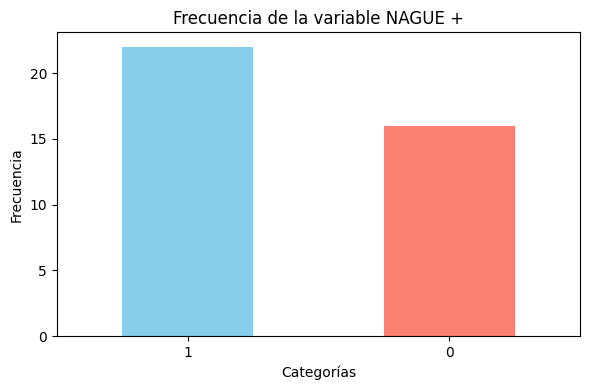

Frecuencias Post-Diálisis:
NAGUE +
0    26
1    12
Name: count, dtype: int64

Proporciones Post-Diálisis:
NAGUE +
0    0.684211
1    0.315789
Name: proportion, dtype: float64


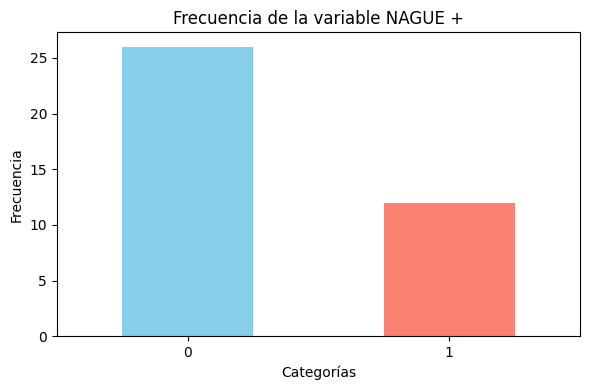

In [43]:
frecuencia_pre = df_pre['NAGUE +'].value_counts()
proporciones_pre = df_pre['NAGUE +'].value_counts(normalize=True)


frecuencia_pos = df_pos['NAGUE +'].value_counts()
proporciones_pos = df_pos['NAGUE +'].value_counts(normalize=True)

print("Frecuencias Pre-Diálisis:")
print(frecuencia_pre)
print("\nProporciones Pre-Diálisis:")
print(proporciones_pre)

# Gráfico de barras
plt.figure(figsize=(6, 4))
df_pre['NAGUE +'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Frecuencia de la variable NAGUE +')
plt.xlabel('Categorías')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Frecuencias Post-Diálisis:")
print(frecuencia_pos)
print("\nProporciones Post-Diálisis:")
print(proporciones_pos)


# Gráfico de barras
plt.figure(figsize=(6, 4))
df_pos['NAGUE +'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Frecuencia de la variable NAGUE +')
plt.xlabel('Categorías')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [31]:
df_wide = df.pivot(index='Paciente', columns='POSDIAL', values='NAGUE +').dropna()
df_wide.columns = ['Antes', 'Despues']

contingency_table = pd.crosstab(df_wide['Antes'], df_wide['Despues'])


result = mcnemar(contingency_table, exact=True)
print(f"\nPrueba de McNemar: p-valor = {result.pvalue:.5f}")

contingency_table


Prueba de McNemar: p-valor = 0.00195


Despues,0,1
Antes,,
0,16,0
1,10,12


## DisfTEI

Frecuencias Pre-Diálisis:
DisfTEI
2.0    26
1.0    11
Name: count, dtype: int64

Proporciones Pre-Diálisis:
DisfTEI
2.0    0.702703
1.0    0.297297
Name: proportion, dtype: float64


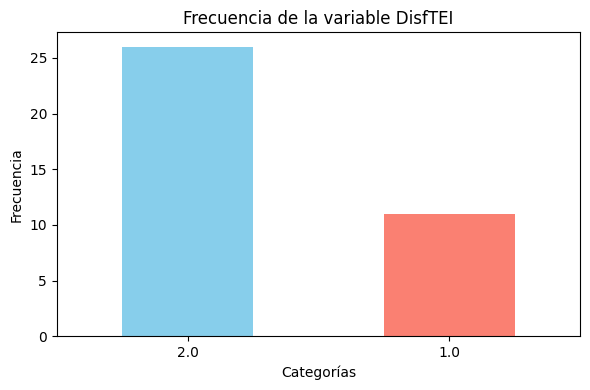

Frecuencias Post-Diálisis:
DisfTEI
2.0    23
1.0    14
Name: count, dtype: int64

Proporciones Post-Diálisis:
DisfTEI
2.0    0.621622
1.0    0.378378
Name: proportion, dtype: float64


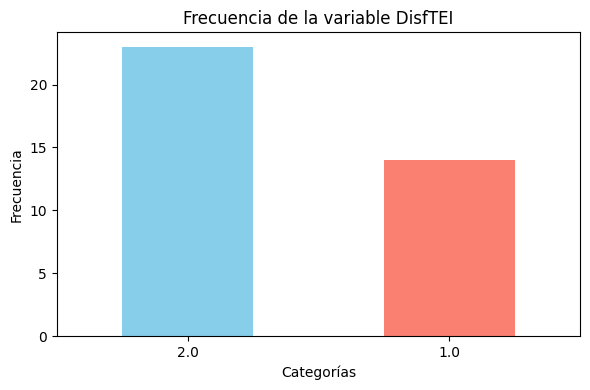

In [46]:
frecuencia_pre = df_pre['DisfTEI'].value_counts()
proporciones_pre = df_pre['DisfTEI'].value_counts(normalize=True)


frecuencia_pos = df_pos['DisfTEI'].value_counts()
proporciones_pos = df_pos['DisfTEI'].value_counts(normalize=True)

print("Frecuencias Pre-Diálisis:")
print(frecuencia_pre)
print("\nProporciones Pre-Diálisis:")
print(proporciones_pre)

# Gráfico de barras
plt.figure(figsize=(6, 4))
df_pre['DisfTEI'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Frecuencia de la variable DisfTEI')
plt.xlabel('Categorías')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Frecuencias Post-Diálisis:")
print(frecuencia_pos)
print("\nProporciones Post-Diálisis:")
print(proporciones_pos)


# Gráfico de barras
plt.figure(figsize=(6, 4))
df_pos['DisfTEI'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Frecuencia de la variable DisfTEI')
plt.xlabel('Categorías')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [47]:
df_wide = df.pivot(index='Paciente', columns='POSDIAL', values='DisfTEI').dropna()
df_wide.columns = ['Antes', 'Despues']

contingency_table = pd.crosstab(df_wide['Antes'], df_wide['Despues'])


result = mcnemar(contingency_table, exact=True)
print(f"\nPrueba de McNemar: p-valor = {result.pvalue:.5f}")

contingency_table


Prueba de McNemar: p-valor = 0.54883


Despues,1.0,2.0
Antes,,
1.0,7,4
2.0,7,19


## Disf TAPSE

Frecuencias Pre-Diálisis:
Disf TAPSE
2.0    32
1.0     5
Name: count, dtype: int64

Proporciones Pre-Diálisis:
Disf TAPSE
2.0    0.864865
1.0    0.135135
Name: proportion, dtype: float64


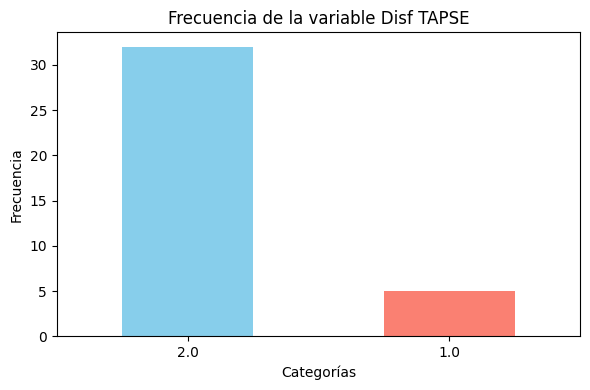

Frecuencias Post-Diálisis:
Disf TAPSE
2.0    29
1.0     8
Name: count, dtype: int64

Proporciones Post-Diálisis:
Disf TAPSE
2.0    0.783784
1.0    0.216216
Name: proportion, dtype: float64


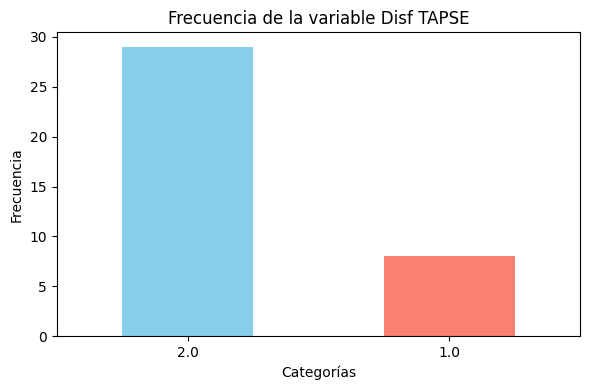

In [49]:
frecuencia_pre = df_pre['Disf TAPSE'].value_counts()
proporciones_pre = df_pre['Disf TAPSE'].value_counts(normalize=True)


frecuencia_pos = df_pos['Disf TAPSE'].value_counts()
proporciones_pos = df_pos['Disf TAPSE'].value_counts(normalize=True)

print("Frecuencias Pre-Diálisis:")
print(frecuencia_pre)
print("\nProporciones Pre-Diálisis:")
print(proporciones_pre)

# Gráfico de barras
plt.figure(figsize=(6, 4))
df_pre['Disf TAPSE'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Frecuencia de la variable Disf TAPSE')
plt.xlabel('Categorías')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Frecuencias Post-Diálisis:")
print(frecuencia_pos)
print("\nProporciones Post-Diálisis:")
print(proporciones_pos)


# Gráfico de barras
plt.figure(figsize=(6, 4))
df_pos['Disf TAPSE'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Frecuencia de la variable Disf TAPSE')
plt.xlabel('Categorías')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Corte en 17 -  Guia de evaluacion de cavidades derechas.Guidelines for echocardiographyc assasment of the rigth heart in adult. JASE 2010 

In [50]:
df_wide = df.pivot(index='Paciente', columns='POSDIAL', values='Disf TAPSE').dropna()
df_wide.columns = ['Antes', 'Despues']

contingency_table = pd.crosstab(df_wide['Antes'], df_wide['Despues'])


result = mcnemar(contingency_table, exact=True)
print(f"\nPrueba de McNemar: p-valor = {result.pvalue:.5f}")

contingency_table


Prueba de McNemar: p-valor = 0.37500


Despues,1.0,2.0
Antes,,
1.0,4,1
2.0,4,28


## Disf FAC

Frecuencias Pre-Diálisis:
Disf FAC
2.0    32
1.0     4
Name: count, dtype: int64

Proporciones Pre-Diálisis:
Disf FAC
2.0    0.888889
1.0    0.111111
Name: proportion, dtype: float64


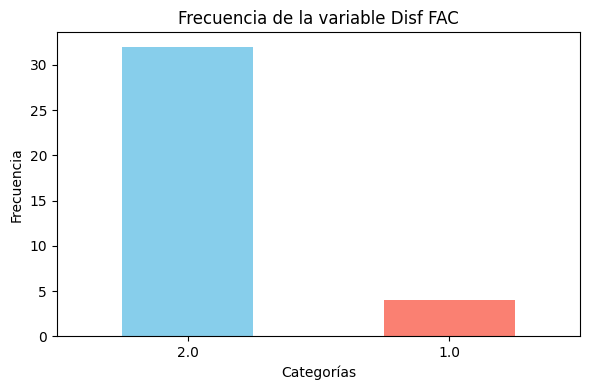

Frecuencias Post-Diálisis:
Disf FAC
2.0    30
1.0     6
Name: count, dtype: int64

Proporciones Post-Diálisis:
Disf FAC
2.0    0.833333
1.0    0.166667
Name: proportion, dtype: float64


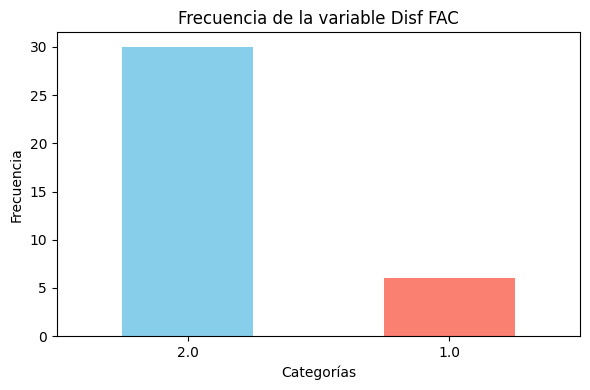

In [51]:
frecuencia_pre = df_pre['Disf FAC'].value_counts()
proporciones_pre = df_pre['Disf FAC'].value_counts(normalize=True)


frecuencia_pos = df_pos['Disf FAC'].value_counts()
proporciones_pos = df_pos['Disf FAC'].value_counts(normalize=True)

print("Frecuencias Pre-Diálisis:")
print(frecuencia_pre)
print("\nProporciones Pre-Diálisis:")
print(proporciones_pre)

# Gráfico de barras
plt.figure(figsize=(6, 4))
df_pre['Disf FAC'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Frecuencia de la variable Disf FAC')
plt.xlabel('Categorías')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Frecuencias Post-Diálisis:")
print(frecuencia_pos)
print("\nProporciones Post-Diálisis:")
print(proporciones_pos)


# Gráfico de barras
plt.figure(figsize=(6, 4))
df_pos['Disf FAC'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Frecuencia de la variable Disf FAC')
plt.xlabel('Categorías')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [52]:
df_wide = df.pivot(index='Paciente', columns='POSDIAL', values='Disf FAC').dropna()
df_wide.columns = ['Antes', 'Despues']

contingency_table = pd.crosstab(df_wide['Antes'], df_wide['Despues'])


result = mcnemar(contingency_table, exact=True)
print(f"\nPrueba de McNemar: p-valor = {result.pvalue:.5f}")

contingency_table


Prueba de McNemar: p-valor = 0.62500


Despues,1.0,2.0
Antes,,
1.0,3,1
2.0,3,29


## Disf Stis

Frecuencias Pre-Diálisis:
Disf Stis
2.0    31
1.0     6
Name: count, dtype: int64

Proporciones Pre-Diálisis:
Disf Stis
2.0    0.837838
1.0    0.162162
Name: proportion, dtype: float64


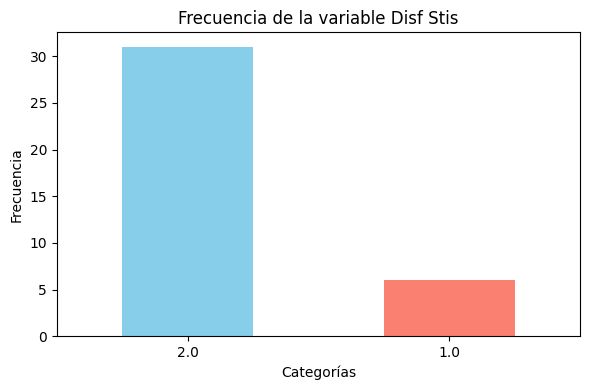

Frecuencias Post-Diálisis:
Disf Stis
2.0    24
1.0    13
Name: count, dtype: int64

Proporciones Post-Diálisis:
Disf Stis
2.0    0.648649
1.0    0.351351
Name: proportion, dtype: float64


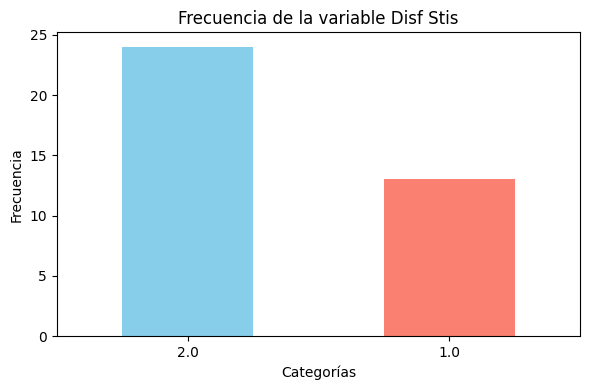

In [53]:
frecuencia_pre = df_pre['Disf Stis'].value_counts()
proporciones_pre = df_pre['Disf Stis'].value_counts(normalize=True)


frecuencia_pos = df_pos['Disf Stis'].value_counts()
proporciones_pos = df_pos['Disf Stis'].value_counts(normalize=True)

print("Frecuencias Pre-Diálisis:")
print(frecuencia_pre)
print("\nProporciones Pre-Diálisis:")
print(proporciones_pre)

# Gráfico de barras
plt.figure(figsize=(6, 4))
df_pre['Disf Stis'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Frecuencia de la variable Disf Stis')
plt.xlabel('Categorías')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Frecuencias Post-Diálisis:")
print(frecuencia_pos)
print("\nProporciones Post-Diálisis:")
print(proporciones_pos)


# Gráfico de barras
plt.figure(figsize=(6, 4))
df_pos['Disf Stis'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Frecuencia de la variable Disf Stis')
plt.xlabel('Categorías')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [54]:
df_wide = df.pivot(index='Paciente', columns='POSDIAL', values='Disf Stis').dropna()
df_wide.columns = ['Antes', 'Despues']

contingency_table = pd.crosstab(df_wide['Antes'], df_wide['Despues'])


result = mcnemar(contingency_table, exact=True)
print(f"\nPrueba de McNemar: p-valor = {result.pvalue:.5f}")

contingency_table


Prueba de McNemar: p-valor = 0.03906


Despues,1.0,2.0
Antes,,
1.0,5,1
2.0,8,23


## IT

Frecuencias Pre-Diálisis:
IT
1    24
0    12
2     1
3     1
Name: count, dtype: int64

Proporciones Pre-Diálisis:
IT
1    0.631579
0    0.315789
2    0.026316
3    0.026316
Name: proportion, dtype: float64


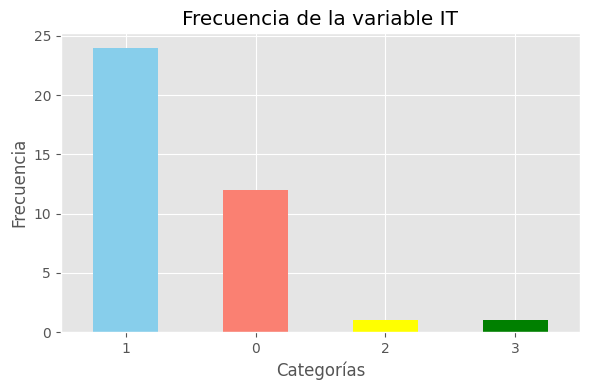

Frecuencias Post-Diálisis:
IT
0    20
1    16
2     1
3     1
Name: count, dtype: int64

Proporciones Post-Diálisis:
IT
0    0.526316
1    0.421053
2    0.026316
3    0.026316
Name: proportion, dtype: float64


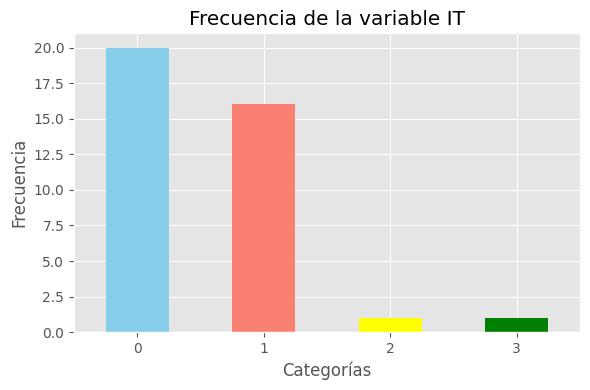

In [80]:
frecuencia_pre = df_pre['IT'].value_counts()
proporciones_pre = df_pre['IT'].value_counts(normalize=True)


frecuencia_pos = df_pos['IT'].value_counts()
proporciones_pos = df_pos['IT'].value_counts(normalize=True)

print("Frecuencias Pre-Diálisis:")
print(frecuencia_pre)
print("\nProporciones Pre-Diálisis:")
print(proporciones_pre)

# Gráfico de barras
plt.figure(figsize=(6, 4))
df_pre['IT'].value_counts().plot(kind='bar', color=['skyblue', 'salmon', 'yellow', 'green'])
plt.title('Frecuencia de la variable IT')
plt.xlabel('Categorías')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Frecuencias Post-Diálisis:")
print(frecuencia_pos)
print("\nProporciones Post-Diálisis:")
print(proporciones_pos)


# Gráfico de barras
plt.figure(figsize=(6, 4))
df_pos['IT'].value_counts().plot(kind='bar', color=['skyblue', 'salmon', 'yellow', 'green'])
plt.title('Frecuencia de la variable IT')
plt.xlabel('Categorías')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# Leve, moderada, severa, sin it

In [56]:
df_wide = df.pivot(index='Paciente', columns='POSDIAL', values='IT').dropna()
df_wide.columns = ['Antes', 'Despues']

contingency_table = pd.crosstab(df_wide['Antes'], df_wide['Despues'])


result = mcnemar(contingency_table, exact=True)
print(f"\nPrueba de McNemar: p-valor = {result.pvalue:.5f}")

contingency_table


Prueba de McNemar: p-valor = 0.02148


Despues,0,1,2,3
Antes,,,,
0,11,1,0,0
1,9,15,0,0
2,0,0,1,0
3,0,0,0,1


## CAVA

In [76]:
df['CAVA'].value_counts()
# Sin dilatar colapsante 1, dilatada sin colapso 3, intermedia 2

CAVA
1    47
3    15
2    14
Name: count, dtype: int64

In [77]:
df['CAVA'].isna().sum()

0

Frecuencias Pre-Diálisis:
CAVA
1    15
3    12
2    11
Name: count, dtype: int64

Proporciones Pre-Diálisis:
CAVA
1    0.394737
3    0.315789
2    0.289474
Name: proportion, dtype: float64


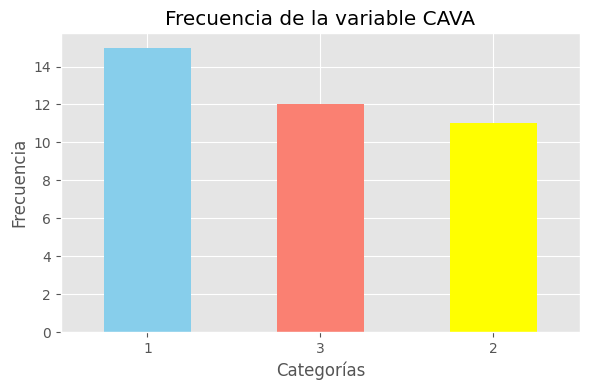

Frecuencias Post-Diálisis:
CAVA
1    32
3     3
2     3
Name: count, dtype: int64

Proporciones Post-Diálisis:
CAVA
1    0.842105
3    0.078947
2    0.078947
Name: proportion, dtype: float64


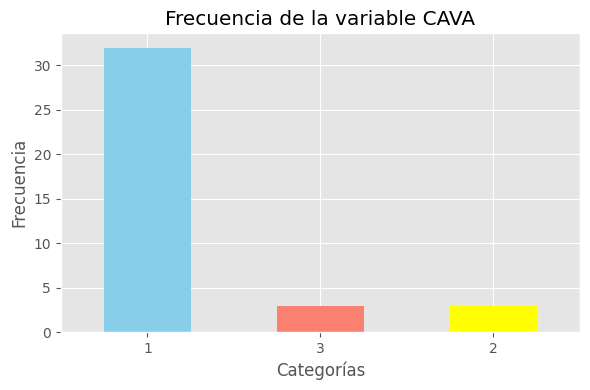

In [81]:
frecuencia_pre = df_pre['CAVA'].value_counts()
proporciones_pre = df_pre['CAVA'].value_counts(normalize=True)


frecuencia_pos = df_pos['CAVA'].value_counts()
proporciones_pos = df_pos['CAVA'].value_counts(normalize=True)

print("Frecuencias Pre-Diálisis:")
print(frecuencia_pre)
print("\nProporciones Pre-Diálisis:")
print(proporciones_pre)

# Gráfico de barras
plt.figure(figsize=(6, 4))
df_pre['CAVA'].value_counts().plot(kind='bar', color=['skyblue', 'salmon', 'yellow'])
plt.title('Frecuencia de la variable CAVA')
plt.xlabel('Categorías')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Frecuencias Post-Diálisis:")
print(frecuencia_pos)
print("\nProporciones Post-Diálisis:")
print(proporciones_pos)


# Gráfico de barras
plt.figure(figsize=(6, 4))
df_pos['CAVA'].value_counts().plot(kind='bar', color=['skyblue', 'salmon', 'yellow'])
plt.title('Frecuencia de la variable CAVA')
plt.xlabel('Categorías')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [82]:
df_wide = df.pivot(index='Paciente', columns='POSDIAL', values='CAVA').dropna()
df_wide.columns = ['Antes', 'Despues']

contingency_table = pd.crosstab(df_wide['Antes'], df_wide['Despues'])


result = mcnemar(contingency_table, exact=True)
print(f"\nPrueba de McNemar: p-valor = {result.pvalue:.5f}")

contingency_table


Prueba de McNemar: p-valor = 0.00098


Despues,1,2,3
Antes,,,
1,15,0,0
2,11,0,0
3,6,3,3


## PORT

In [84]:
df_pre['PORT'].value_counts()

PORT
1    15
2    12
3    11
Name: count, dtype: int64

In [85]:
df_pre['PORT'].isna().sum()

0

Frecuencias Pre-Diálisis:
PORT
1    15
2    12
3    11
Name: count, dtype: int64

Proporciones Pre-Diálisis:
PORT
1    0.394737
2    0.315789
3    0.289474
Name: proportion, dtype: float64


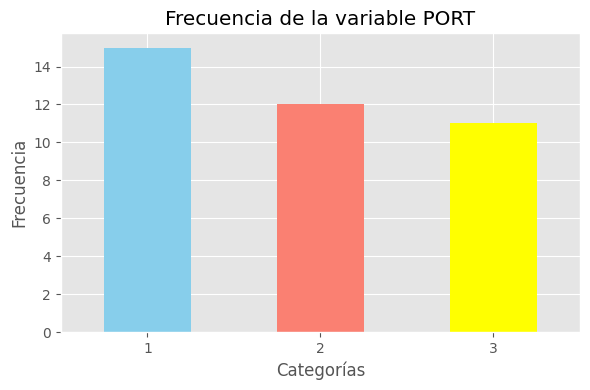

Frecuencias Post-Diálisis:
PORT
1    28
2     9
3     1
Name: count, dtype: int64

Proporciones Post-Diálisis:
PORT
1    0.736842
2    0.236842
3    0.026316
Name: proportion, dtype: float64


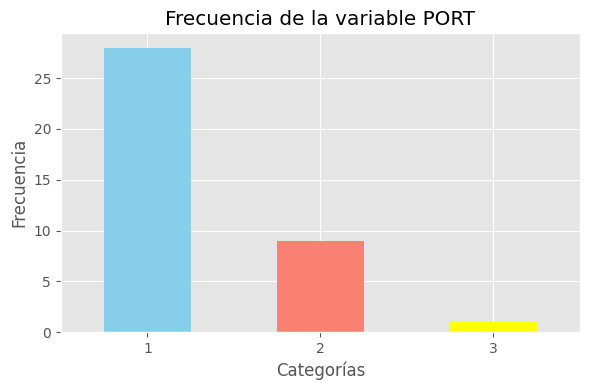

In [86]:
frecuencia_pre = df_pre['PORT'].value_counts()
proporciones_pre = df_pre['PORT'].value_counts(normalize=True)


frecuencia_pos = df_pos['PORT'].value_counts()
proporciones_pos = df_pos['PORT'].value_counts(normalize=True)

print("Frecuencias Pre-Diálisis:")
print(frecuencia_pre)
print("\nProporciones Pre-Diálisis:")
print(proporciones_pre)

# Gráfico de barras
plt.figure(figsize=(6, 4))
df_pre['PORT'].value_counts().plot(kind='bar', color=['skyblue', 'salmon', 'yellow'])
plt.title('Frecuencia de la variable PORT')
plt.xlabel('Categorías')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Frecuencias Post-Diálisis:")
print(frecuencia_pos)
print("\nProporciones Post-Diálisis:")
print(proporciones_pos)


# Gráfico de barras
plt.figure(figsize=(6, 4))
df_pos['PORT'].value_counts().plot(kind='bar', color=['skyblue', 'salmon', 'yellow'])
plt.title('Frecuencia de la variable PORT')
plt.xlabel('Categorías')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [87]:
df_wide = df.pivot(index='Paciente', columns='POSDIAL', values='PORT').dropna()
df_wide.columns = ['Antes', 'Despues']

contingency_table = pd.crosstab(df_wide['Antes'], df_wide['Despues'])


result = mcnemar(contingency_table, exact=True)
print(f"\nPrueba de McNemar: p-valor = {result.pvalue:.5f}")

contingency_table


Prueba de McNemar: p-valor = 0.01562


Despues,1,2,3
Antes,,,
1,15,0,0
2,7,5,0
3,6,4,1


## SUPRAH

In [92]:
df_pre['Eeprim VD 6'].value_counts()

Eeprim VD 6
1.0    26
0.0    11
Name: count, dtype: int64

Frecuencias Pre-Diálisis:
Eeprim VD 6
1.0    26
0.0    11
Name: count, dtype: int64

Proporciones Pre-Diálisis:
Eeprim VD 6
1.0    0.702703
0.0    0.297297
Name: proportion, dtype: float64


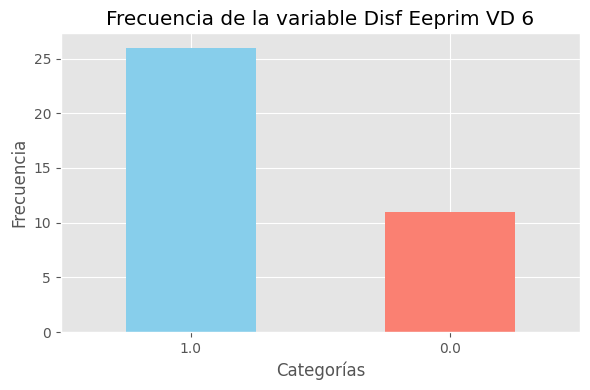

Frecuencias Post-Diálisis:
Eeprim VD 6
1.0    21
0.0    16
Name: count, dtype: int64

Proporciones Post-Diálisis:
Eeprim VD 6
1.0    0.567568
0.0    0.432432
Name: proportion, dtype: float64


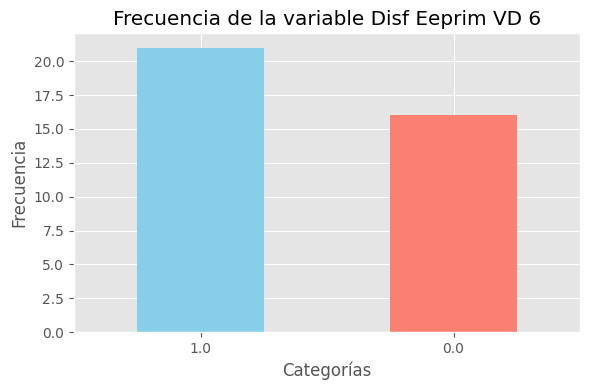

In [93]:
frecuencia_pre = df_pre['Eeprim VD 6'].value_counts()
proporciones_pre = df_pre['Eeprim VD 6'].value_counts(normalize=True)


frecuencia_pos = df_pos['Eeprim VD 6'].value_counts()
proporciones_pos = df_pos['Eeprim VD 6'].value_counts(normalize=True)

print("Frecuencias Pre-Diálisis:")
print(frecuencia_pre)
print("\nProporciones Pre-Diálisis:")
print(proporciones_pre)

# Gráfico de barras
plt.figure(figsize=(6, 4))
df_pre['Eeprim VD 6'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Frecuencia de la variable Disf Eeprim VD 6')
plt.xlabel('Categorías')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Frecuencias Post-Diálisis:")
print(frecuencia_pos)
print("\nProporciones Post-Diálisis:")
print(proporciones_pos)


# Gráfico de barras
plt.figure(figsize=(6, 4))
df_pos['Eeprim VD 6'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Frecuencia de la variable Disf Eeprim VD 6')
plt.xlabel('Categorías')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 1 significa mayor a 6

In [94]:
df_wide = df.pivot(index='Paciente', columns='POSDIAL', values='Eeprim VD 6').dropna()
df_wide.columns = ['Antes', 'Despues']

contingency_table = pd.crosstab(df_wide['Antes'], df_wide['Despues'])


result = mcnemar(contingency_table, exact=True)
print(f"\nPrueba de McNemar: p-valor = {result.pvalue:.5f}")

contingency_table


Prueba de McNemar: p-valor = 0.22656


Despues,0.0,1.0
Antes,,
0.0,8,3
1.0,8,18


## FEVI

Frecuencias Pre-Diálisis:
FEVI
1    26
3     7
2     5
Name: count, dtype: int64

Proporciones Pre-Diálisis:
FEVI
1    0.684211
3    0.184211
2    0.131579
Name: proportion, dtype: float64


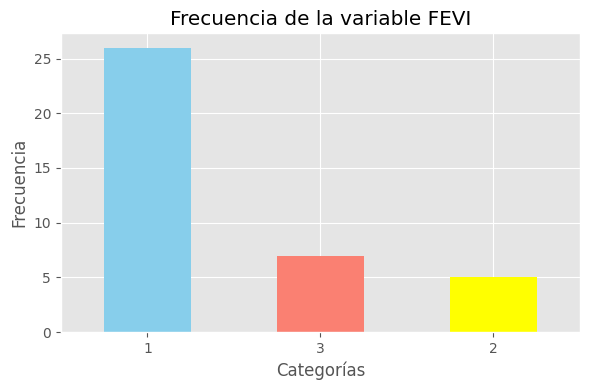

Frecuencias Post-Diálisis:
FEVI
1    26
3     7
2     5
Name: count, dtype: int64

Proporciones Post-Diálisis:
FEVI
1    0.684211
3    0.184211
2    0.131579
Name: proportion, dtype: float64


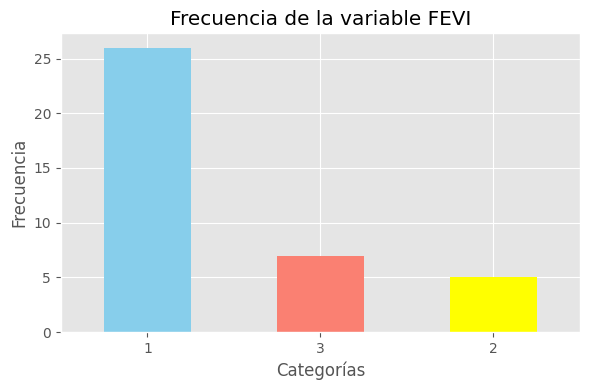

In [98]:
frecuencia_pre = df_pre['FEVI'].value_counts()
proporciones_pre = df_pre['FEVI'].value_counts(normalize=True)


frecuencia_pos = df_pos['FEVI'].value_counts()
proporciones_pos = df_pos['FEVI'].value_counts(normalize=True)

print("Frecuencias Pre-Diálisis:")
print(frecuencia_pre)
print("\nProporciones Pre-Diálisis:")
print(proporciones_pre)

# Gráfico de barras
plt.figure(figsize=(6, 4))
df_pre['FEVI'].value_counts().plot(kind='bar', color=['skyblue', 'salmon', 'yellow'])
plt.title('Frecuencia de la variable FEVI')
plt.xlabel('Categorías')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Frecuencias Post-Diálisis:")
print(frecuencia_pos)
print("\nProporciones Post-Diálisis:")
print(proporciones_pos)


# Gráfico de barras
plt.figure(figsize=(6, 4))
df_pos['FEVI'].value_counts().plot(kind='bar', color=['skyblue', 'salmon', 'yellow'])
plt.title('Frecuencia de la variable FEVI')
plt.xlabel('Categorías')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [99]:
df_wide = df.pivot(index='Paciente', columns='POSDIAL', values='FEVI').dropna()
df_wide.columns = ['Antes', 'Despues']

contingency_table = pd.crosstab(df_wide['Antes'], df_wide['Despues'])


result = mcnemar(contingency_table, exact=True)
print(f"\nPrueba de McNemar: p-valor = {result.pvalue:.5f}")

contingency_table


Prueba de McNemar: p-valor = 1.00000


Despues,1,2,3
Antes,,,
1,26,0,0
2,0,5,0
3,0,0,7


════════════════════════════════════════════════════════════
Variables excluidas por >70% missing:
set()
════════════════════════════════════════════════════════════

[ANÁLISIS DE VALORES PERDIDOS - VARIABLES INCLUIDAS]
+--------------+-------------------+-----------------+------------------+-----------------+----------+----------+----------+----------+-------------------------+
|   Variable   | Pacientes Totales | Pre-Missing (%) | Post-Missing (%) | Pares Completos | MCAR_HTA | MCAR_DBT | MCAR_SEX | MCAR_DLP | Significativas (p<0.05) |
+--------------+-------------------+-----------------+------------------+-----------------+----------+----------+----------+----------+-------------------------+
|    vel it    |        38         |      34.2%      |      55.3%       |       16        |  0.058   |  0.063   |  0.664   |  0.485   |            0            |
|    Eeprim    |        38         |      0.0%       |       0.0%       |       38        |  1.000   |  1.000   |  1.000   |  1.000 

/Users/bita/.pyenv/versions/3.10.6/envs/traditum/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/bita/.pyenv/versions/3.10.6/envs/traditum/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/bita/.pyenv/versions/3.10.6/envs/traditum/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/bita/.pyenv/versions/3.10.6/envs/traditum/lib/python3.10/site-packages/seaborn/_oldcore.py

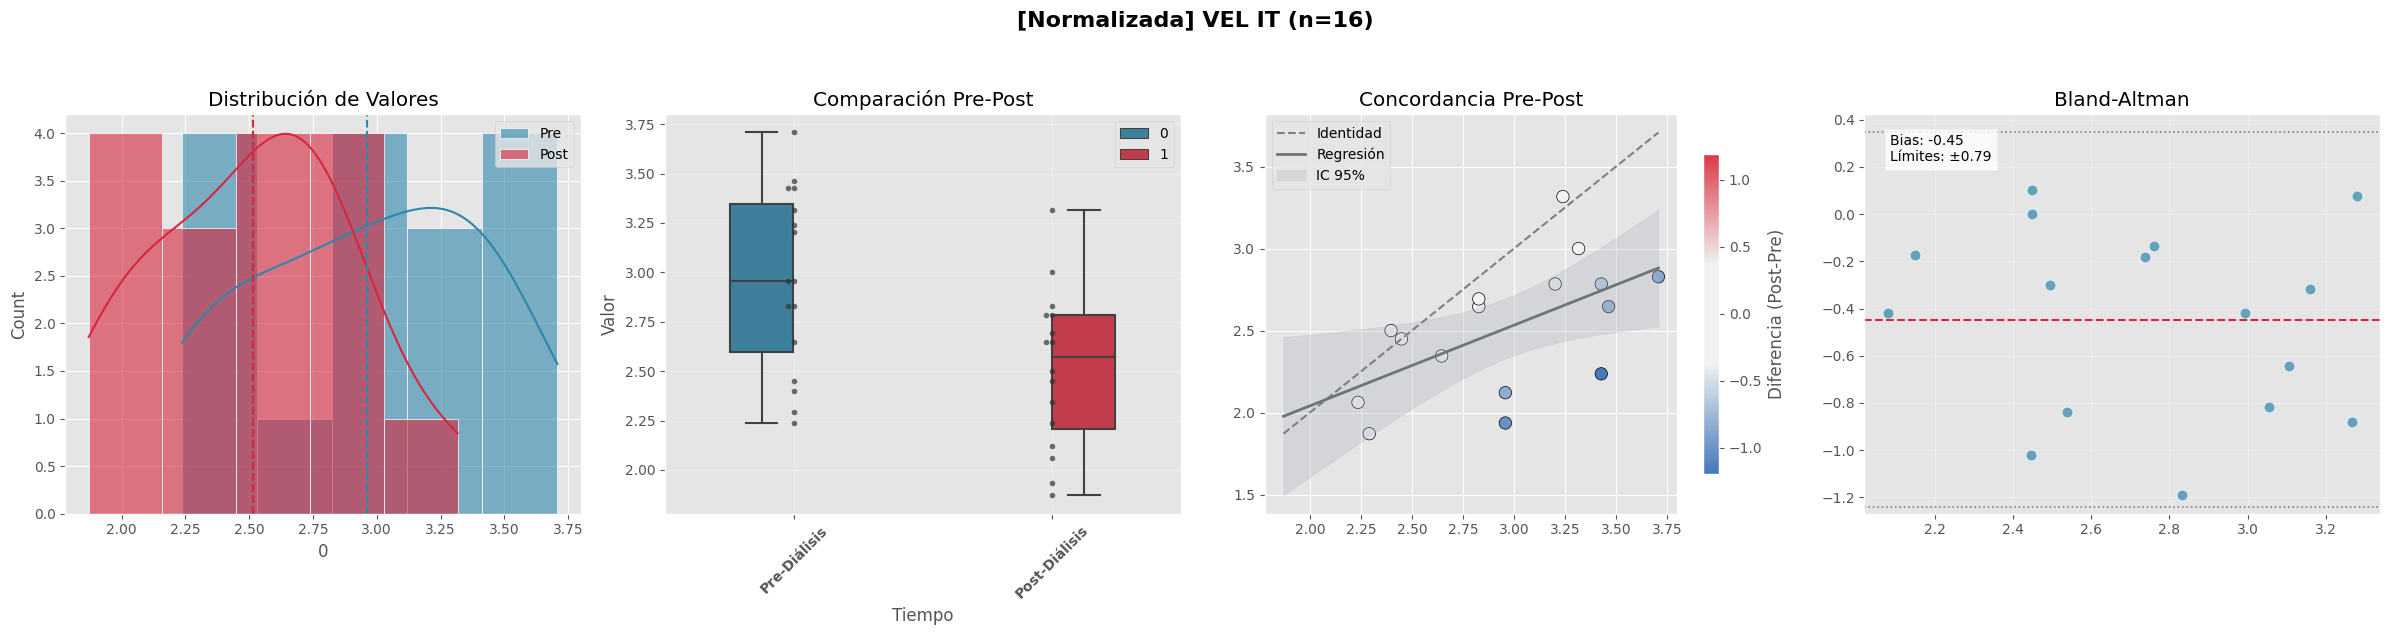


    📊 ANÁLISIS ESTADÍSTICO - VEL IT
    ▪ Diferencia media (IC 95%) [Estandarizada]: -0.91 (-1.35 a -0.47)
    ▪ Diferencia media (IC 95%) [Original]: -0.45 (-0.65 a -0.25)
    ▪ Prueba de normalidad: W = 0.943, p = 0.3814
    ▪ Prueba seleccionada: t(15) = 4.42, p = 0.0005
    ▪ Tamaño del efecto (Cohen's d): -1.11
    ▪ Regresión: y = 1.06 + 0.49x (R² = 0.322)
    ▪ Tamaño de muestra requerido para detectar un efecto significativo en vel it: 9 pacientes.
    
────────────────────────────────────────────────────────────────────────────────


/Users/bita/.pyenv/versions/3.10.6/envs/traditum/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/bita/.pyenv/versions/3.10.6/envs/traditum/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/bita/.pyenv/versions/3.10.6/envs/traditum/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/bita/.pyenv/versions/3.10.6/envs/traditum/lib/python3.10/site-packages/seaborn/_oldcore.py

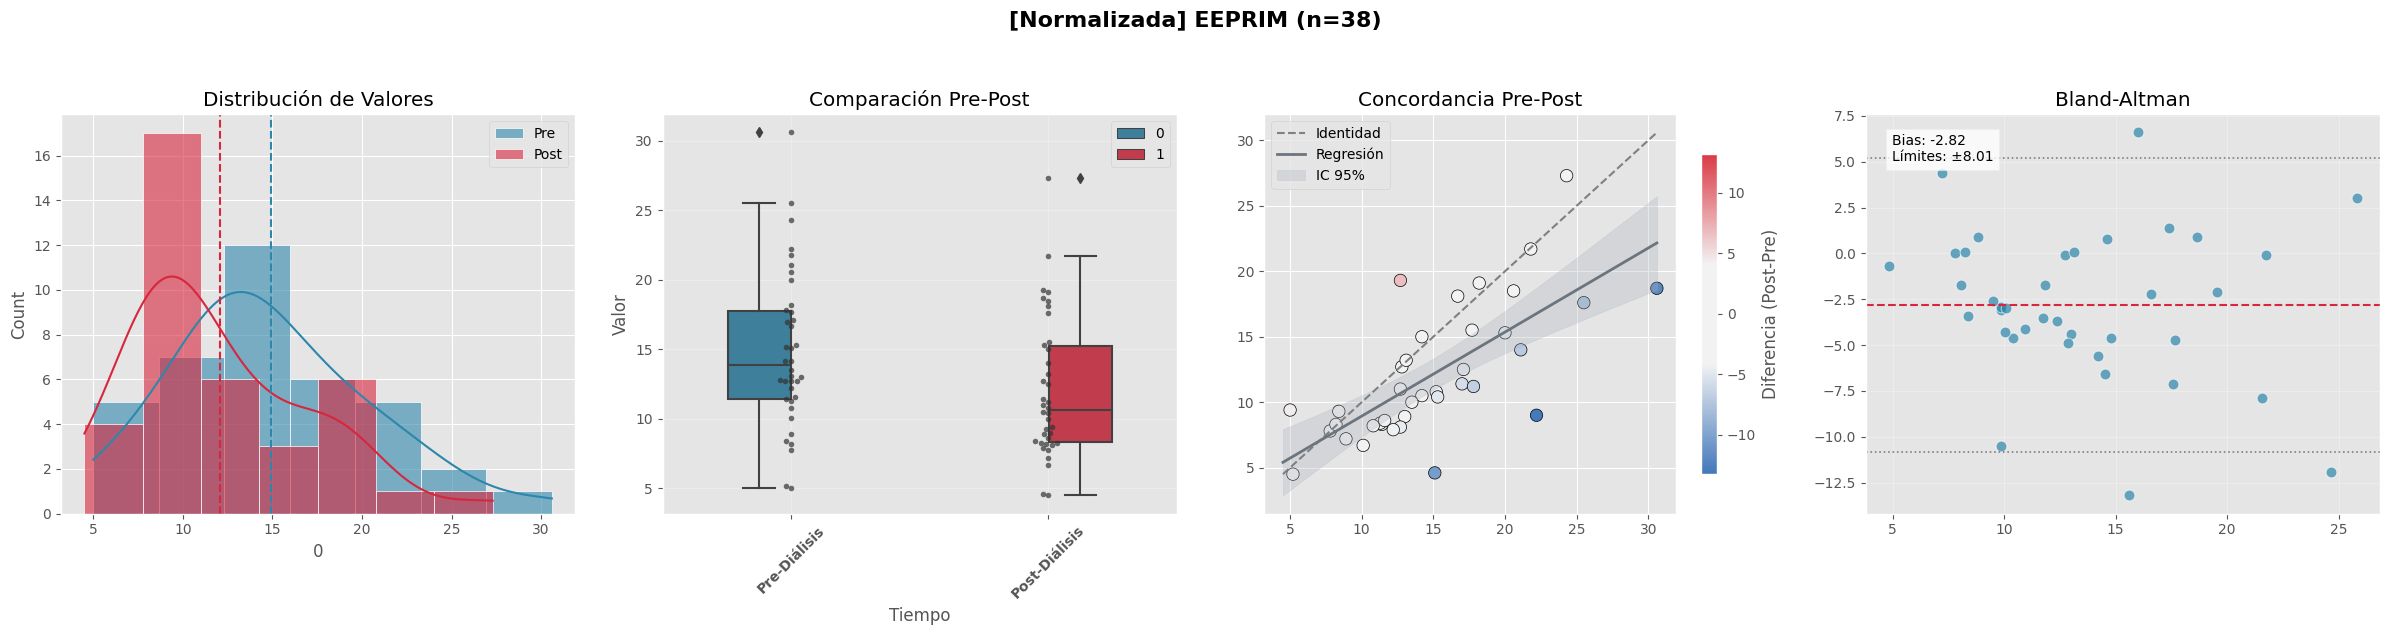


    📊 ANÁLISIS ESTADÍSTICO - EEPRIM
    ▪ Diferencia media (IC 95%) [Estandarizada]: -0.52 (-0.76 a -0.27)
    ▪ Diferencia media (IC 95%) [Original]: -2.82 (-4.12 a -1.52)
    ▪ Prueba de normalidad: W = 0.971, p = 0.4276
    ▪ Prueba seleccionada: t(37) = 4.25, p = 0.0001
    ▪ Tamaño del efecto (Cohen's d): -0.69
    ▪ Regresión: y = 2.52 + 0.64x (R² = 0.505)
    ▪ Tamaño de muestra requerido para detectar un efecto significativo en Eeprim: 19 pacientes.
    
────────────────────────────────────────────────────────────────────────────────


/Users/bita/.pyenv/versions/3.10.6/envs/traditum/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/bita/.pyenv/versions/3.10.6/envs/traditum/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/bita/.pyenv/versions/3.10.6/envs/traditum/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/bita/.pyenv/versions/3.10.6/envs/traditum/lib/python3.10/site-packages/seaborn/_oldcore.py

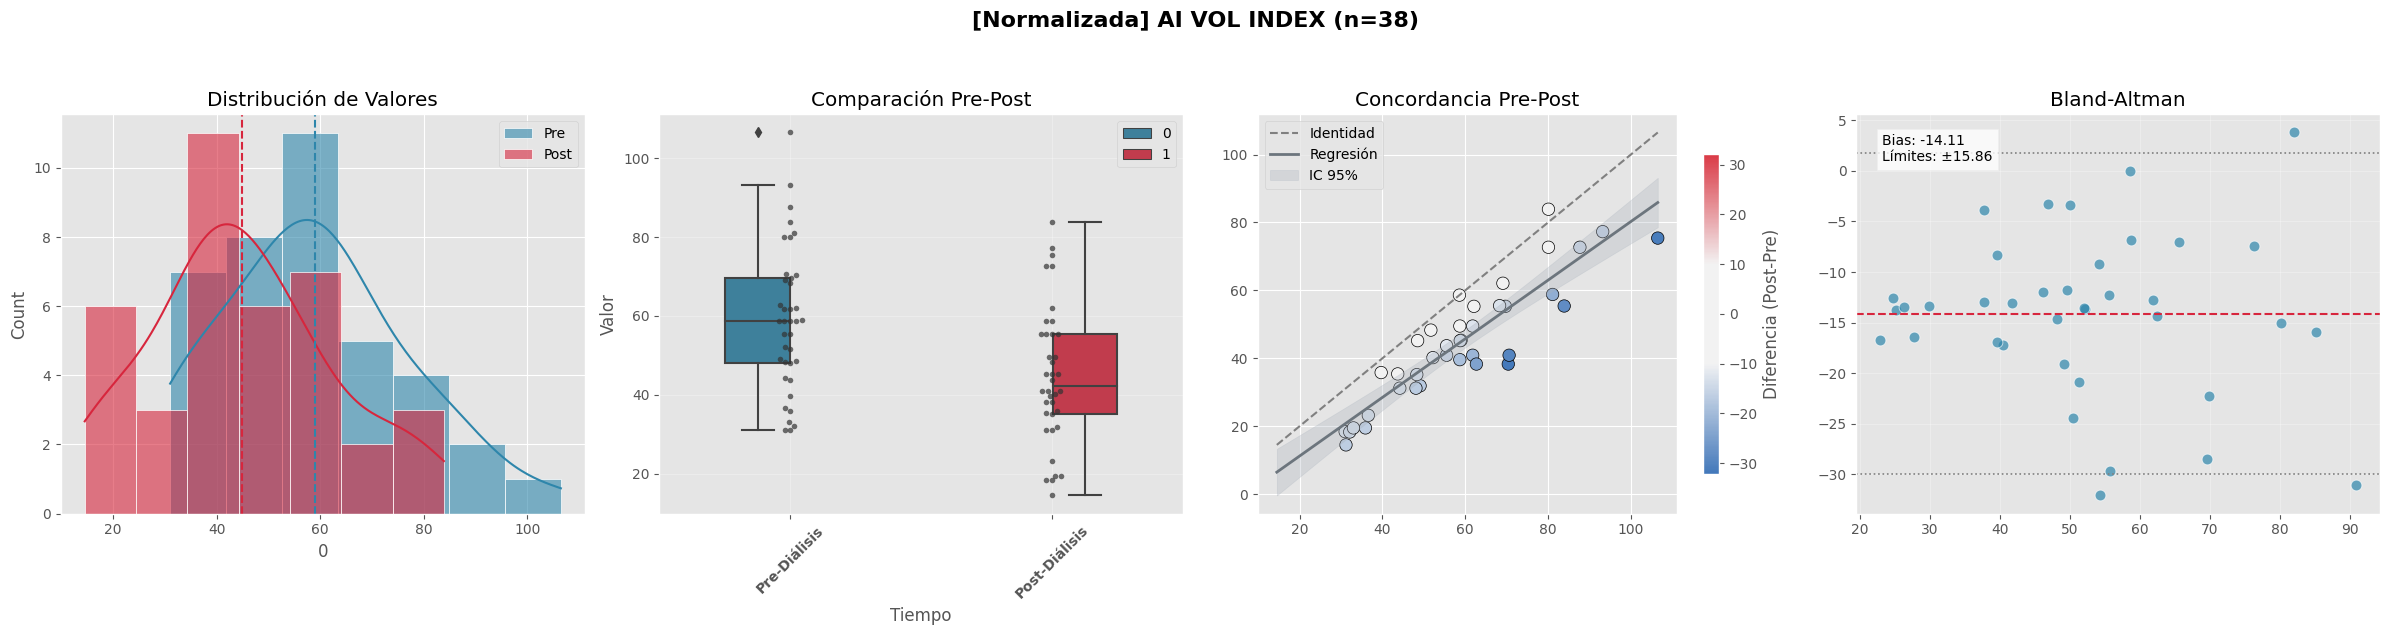


    📊 ANÁLISIS ESTADÍSTICO - AI VOL INDEX
    ▪ Diferencia media (IC 95%) [Estandarizada]: -0.74 (-0.88 a -0.60)
    ▪ Diferencia media (IC 95%) [Original]: -14.11 (-16.69 a -11.54)
    ▪ Prueba de normalidad: W = 0.957, p = 0.1486
    ▪ Prueba seleccionada: t(37) = 10.75, p = 0.0000
    ▪ Tamaño del efecto (Cohen's d): -1.74
    ▪ Regresión: y = -6.04 + 0.86x (R² = 0.806)
    ▪ Tamaño de muestra requerido para detectar un efecto significativo en AI vol index: 5 pacientes.
    
────────────────────────────────────────────────────────────────────────────────


/Users/bita/.pyenv/versions/3.10.6/envs/traditum/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/bita/.pyenv/versions/3.10.6/envs/traditum/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/bita/.pyenv/versions/3.10.6/envs/traditum/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/bita/.pyenv/versions/3.10.6/envs/traditum/lib/python3.10/site-packages/seaborn/_oldcore.py

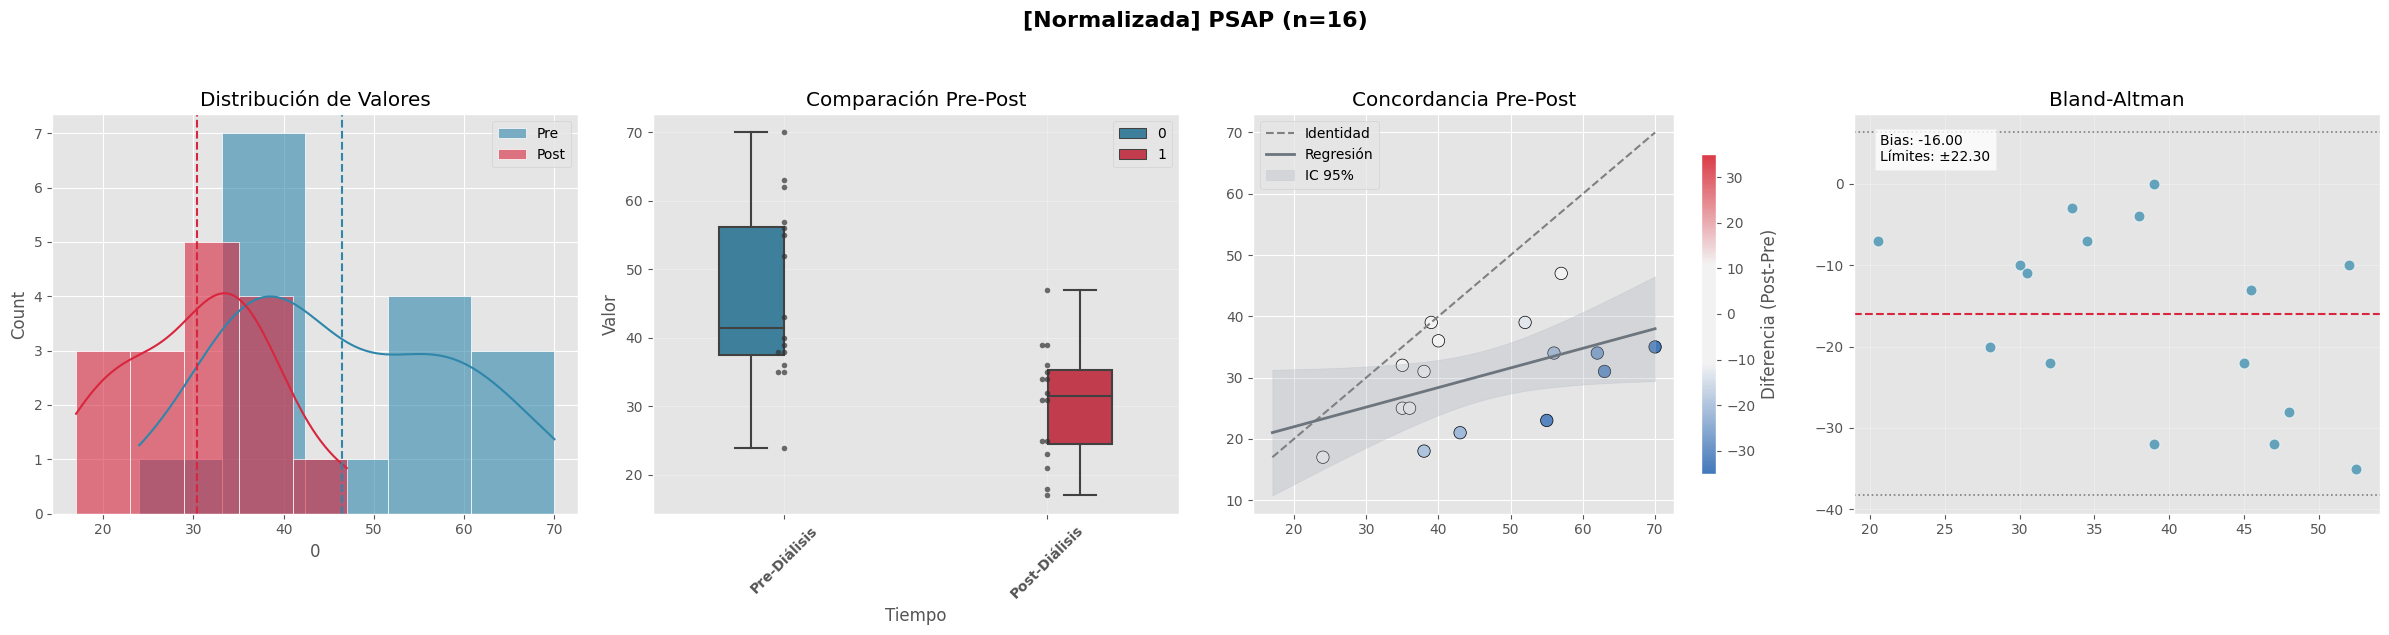


    📊 ANÁLISIS ESTADÍSTICO - PSAP
    ▪ Diferencia media (IC 95%) [Estandarizada]: -1.21 (-1.67 a -0.75)
    ▪ Diferencia media (IC 95%) [Original]: -16.00 (-21.58 a -10.42)
    ▪ Prueba de normalidad: W = 0.925, p = 0.2004
    ▪ Prueba seleccionada: t(15) = 5.62, p = 0.0000
    ▪ Tamaño del efecto (Cohen's d): -1.41
    ▪ Regresión: y = 15.58 + 0.32x (R² = 0.246)
    ▪ Tamaño de muestra requerido para detectar un efecto significativo en PSAP: 7 pacientes.
    
────────────────────────────────────────────────────────────────────────────────


/Users/bita/.pyenv/versions/3.10.6/envs/traditum/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/bita/.pyenv/versions/3.10.6/envs/traditum/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/bita/.pyenv/versions/3.10.6/envs/traditum/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/bita/.pyenv/versions/3.10.6/envs/traditum/lib/python3.10/site-packages/seaborn/_oldcore.py

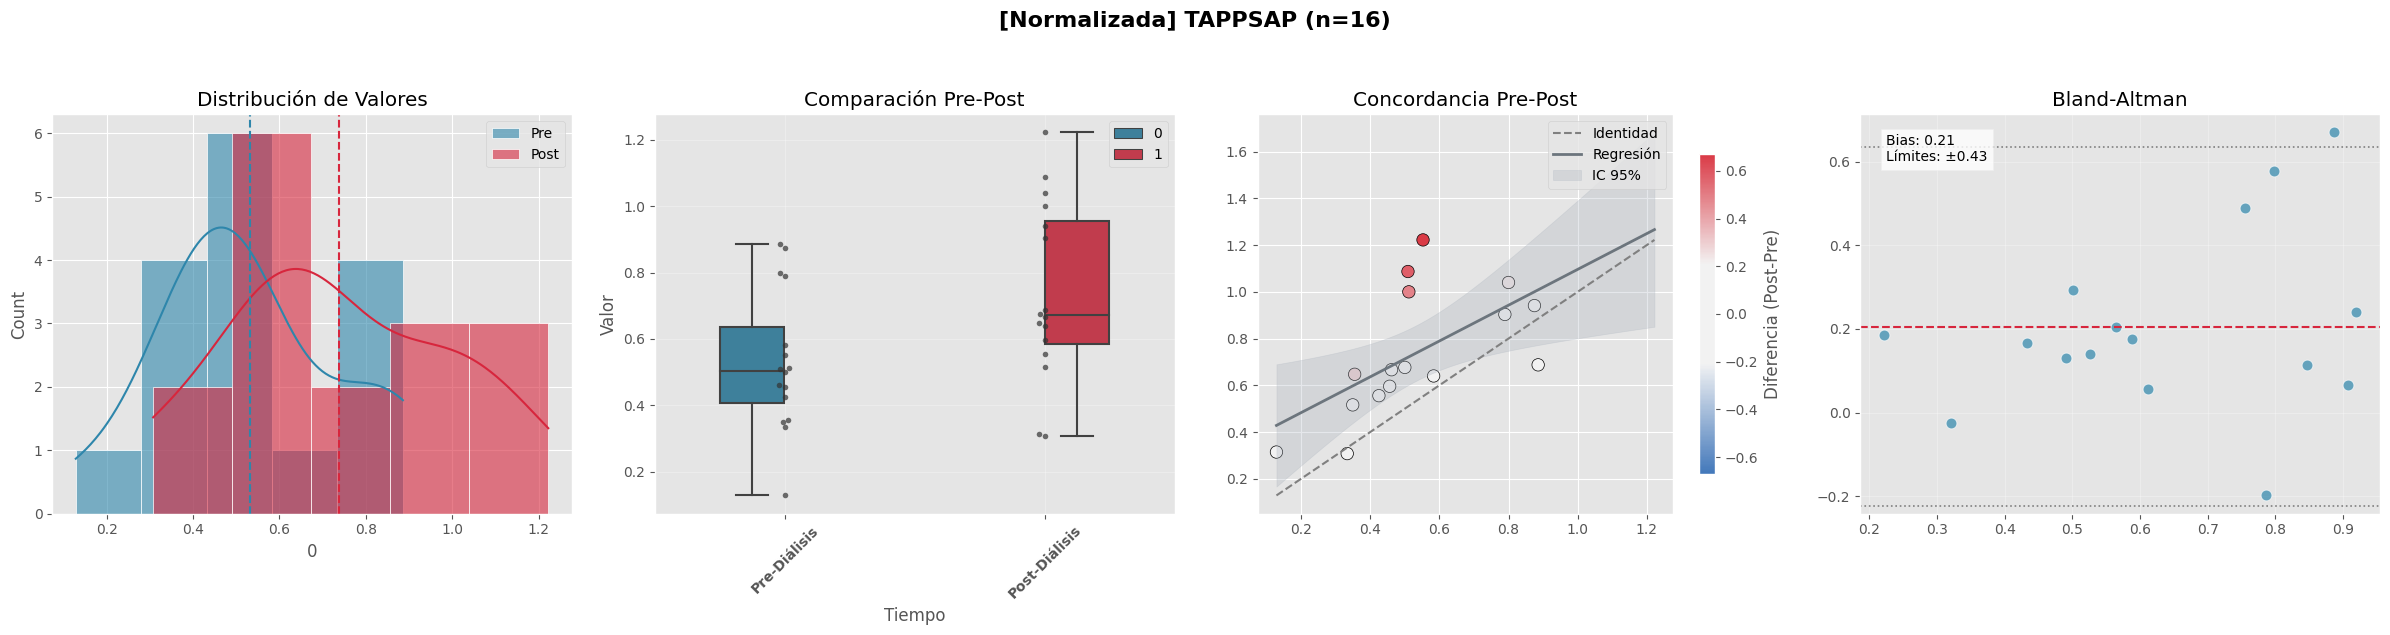


    📊 ANÁLISIS ESTADÍSTICO - TAPPSAP
    ▪ Diferencia media (IC 95%) [Estandarizada]: 0.67 (0.29 a 1.06)
    ▪ Diferencia media (IC 95%) [Original]: 0.21 (0.10 a 0.31)
    ▪ Prueba de normalidad: W = 0.929, p = 0.2308
    ▪ Prueba seleccionada: t(15) = -3.74, p = 0.0020
    ▪ Tamaño del efecto (Cohen's d): 0.94
    ▪ Regresión: y = 0.33 + 0.77x (R² = 0.367)
    ▪ Tamaño de muestra requerido para detectar un efecto significativo en TapPsap: 12 pacientes.
    
────────────────────────────────────────────────────────────────────────────────


/Users/bita/.pyenv/versions/3.10.6/envs/traditum/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/bita/.pyenv/versions/3.10.6/envs/traditum/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/bita/.pyenv/versions/3.10.6/envs/traditum/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/bita/.pyenv/versions/3.10.6/envs/traditum/lib/python3.10/site-packages/seaborn/_oldcore.py

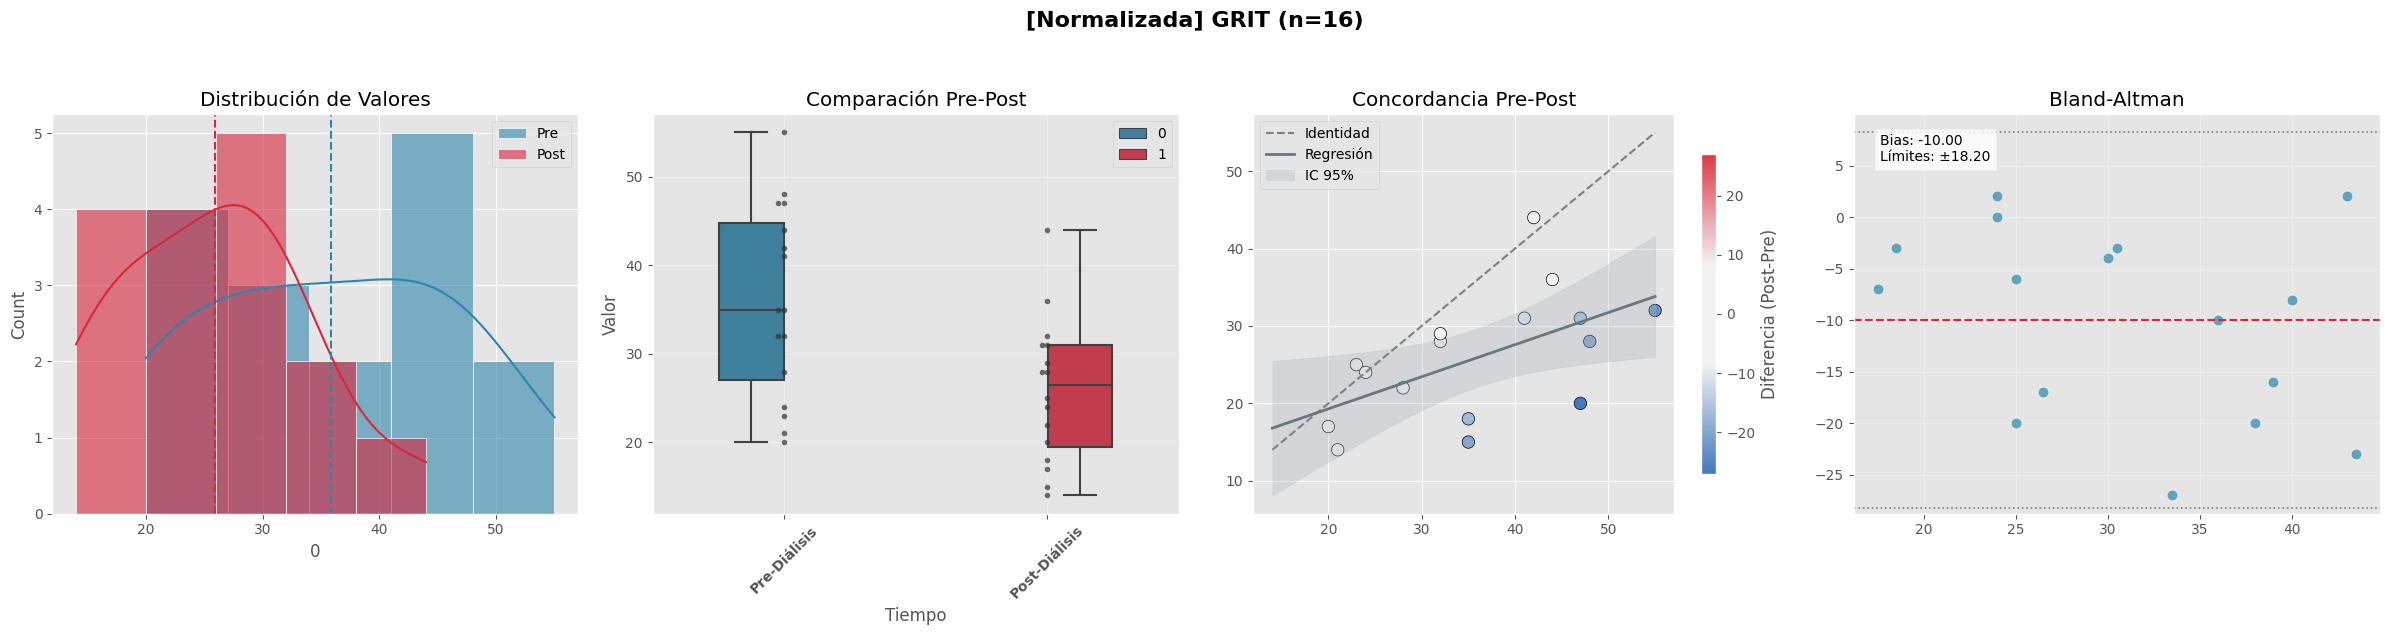


    📊 ANÁLISIS ESTADÍSTICO - GRIT
    ▪ Diferencia media (IC 95%) [Estandarizada]: -0.96 (-1.43 a -0.48)
    ▪ Diferencia media (IC 95%) [Original]: -10.00 (-14.55 a -5.45)
    ▪ Prueba de normalidad: W = 0.931, p = 0.2565
    ▪ Prueba seleccionada: t(15) = 4.31, p = 0.0006
    ▪ Tamaño del efecto (Cohen's d): -1.08
    ▪ Regresión: y = 10.99 + 0.41x (R² = 0.306)
    ▪ Tamaño de muestra requerido para detectar un efecto significativo en grIT: 9 pacientes.
    
────────────────────────────────────────────────────────────────────────────────


/Users/bita/.pyenv/versions/3.10.6/envs/traditum/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/bita/.pyenv/versions/3.10.6/envs/traditum/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/bita/.pyenv/versions/3.10.6/envs/traditum/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/bita/.pyenv/versions/3.10.6/envs/traditum/lib/python3.10/site-packages/seaborn/_oldcore.py

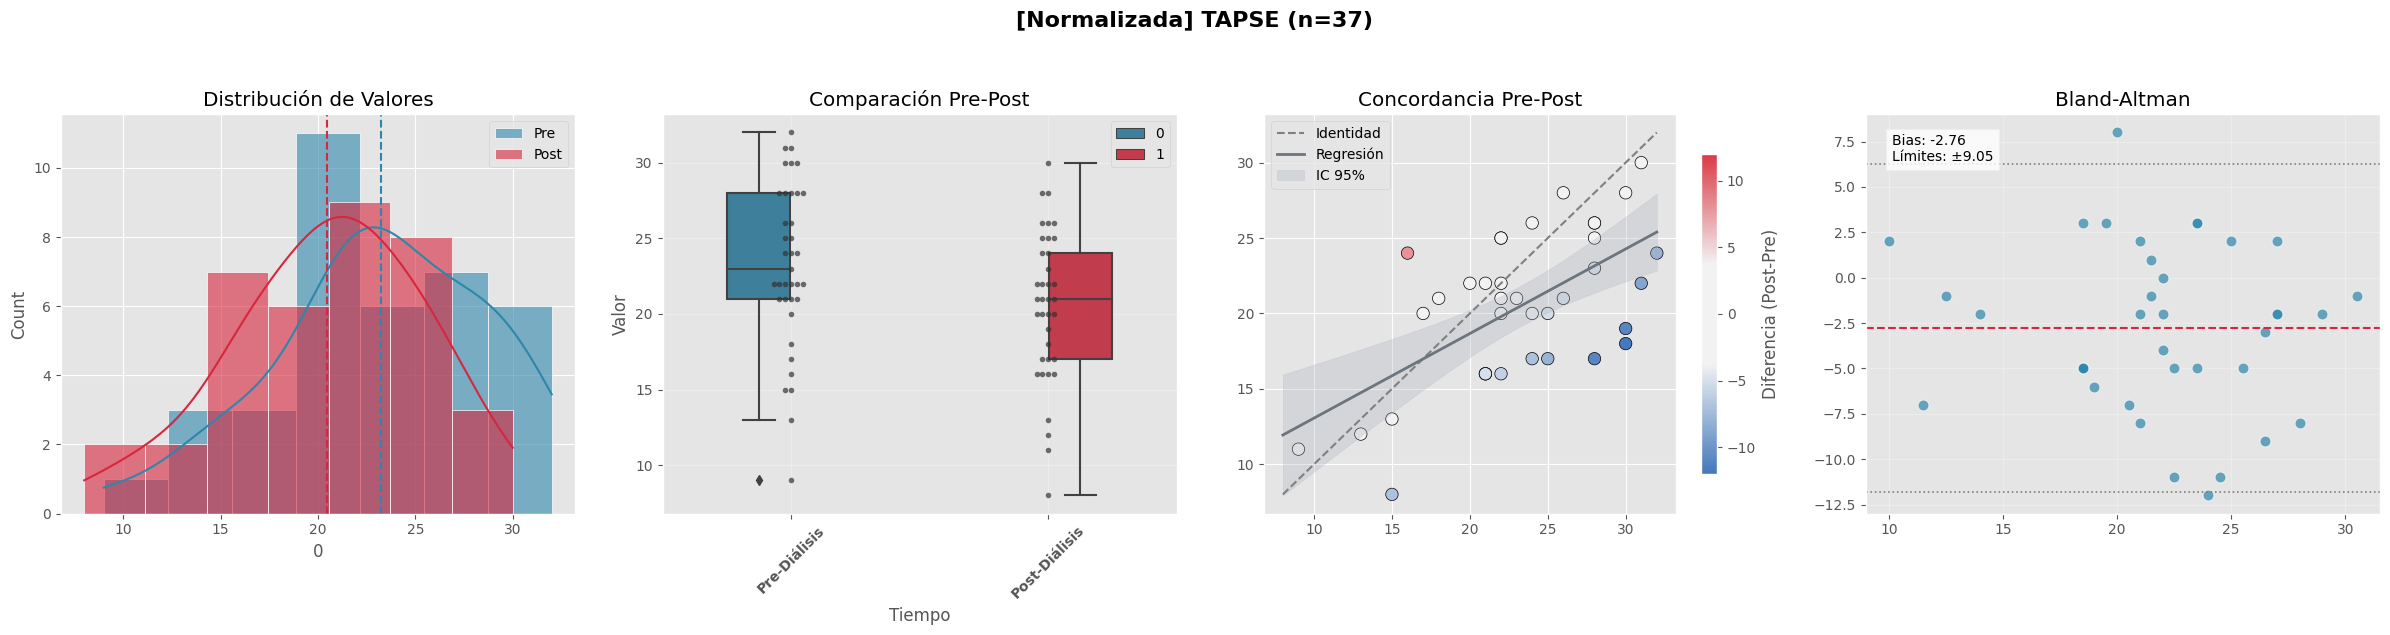


    📊 ANÁLISIS ESTADÍSTICO - TAPSE
    ▪ Diferencia media (IC 95%) [Estandarizada]: -0.52 (-0.80 a -0.23)
    ▪ Diferencia media (IC 95%) [Original]: -2.76 (-4.24 a -1.27)
    ▪ Prueba de normalidad: W = 0.974, p = 0.5302
    ▪ Prueba seleccionada: t(36) = 3.63, p = 0.0009
    ▪ Tamaño del efecto (Cohen's d): -0.60
    ▪ Regresión: y = 7.45 + 0.56x (R² = 0.376)
    ▪ Tamaño de muestra requerido para detectar un efecto significativo en TAPSE: 24 pacientes.
    
────────────────────────────────────────────────────────────────────────────────


/Users/bita/.pyenv/versions/3.10.6/envs/traditum/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/bita/.pyenv/versions/3.10.6/envs/traditum/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/bita/.pyenv/versions/3.10.6/envs/traditum/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/bita/.pyenv/versions/3.10.6/envs/traditum/lib/python3.10/site-packages/seaborn/_oldcore.py

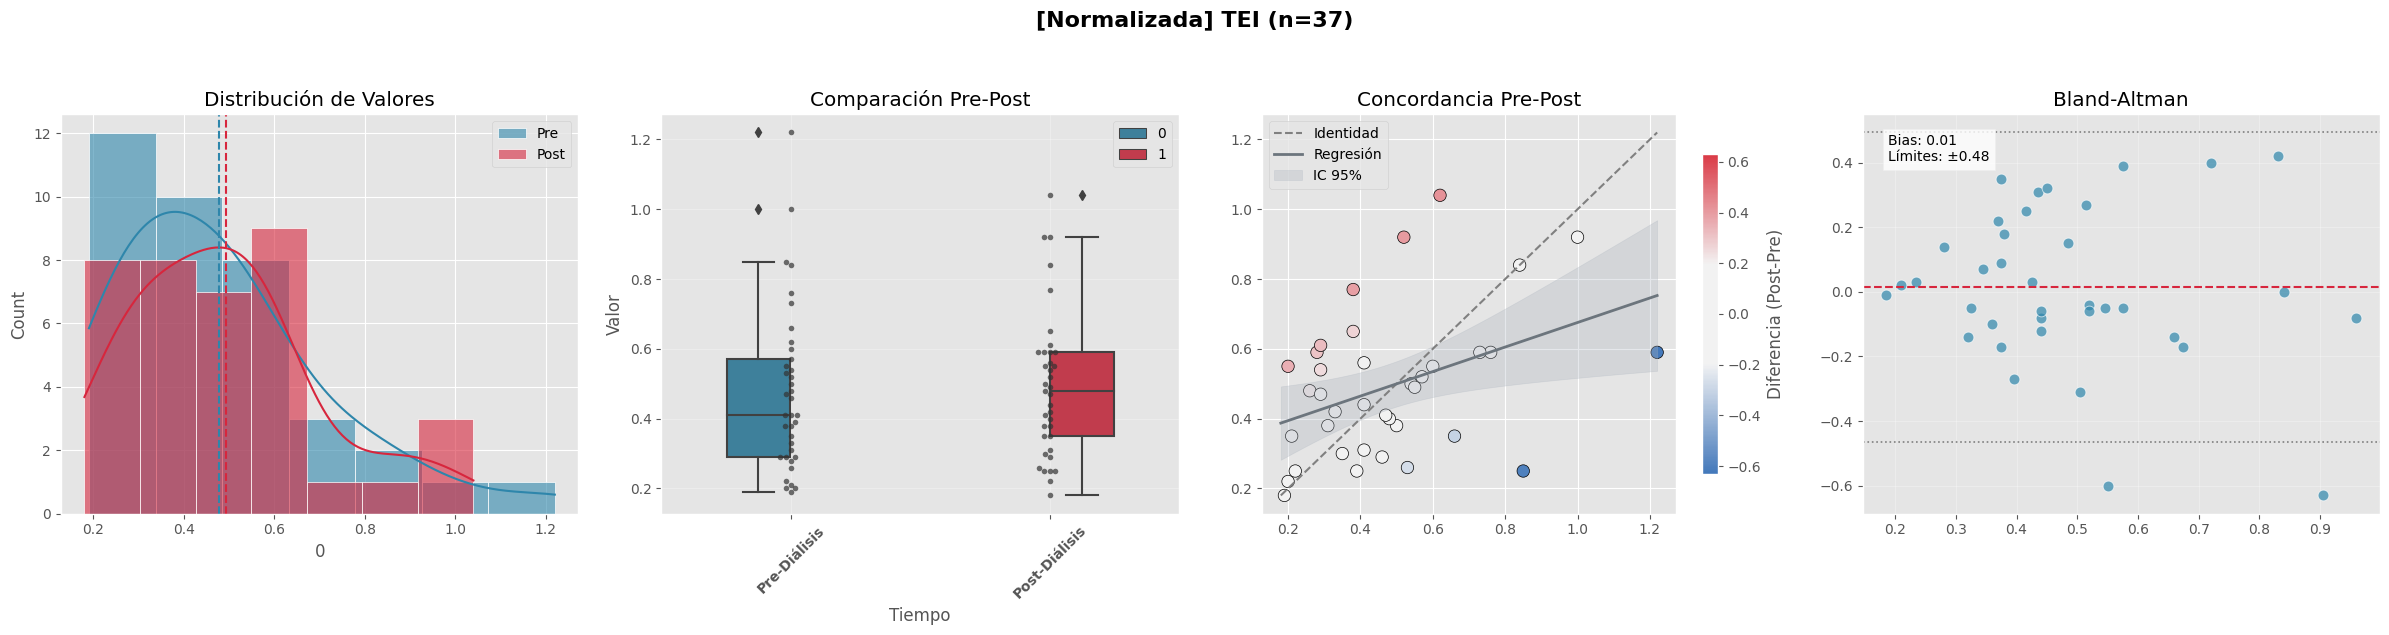


    📊 ANÁLISIS ESTADÍSTICO - TEI
    ▪ Diferencia media (IC 95%) [Estandarizada]: 0.06 (-0.31 a 0.43)
    ▪ Diferencia media (IC 95%) [Original]: 0.01 (-0.07 a 0.09)
    ▪ Prueba de normalidad: W = 0.946, p = 0.0725
    ▪ Prueba seleccionada: t(36) = -0.34, p = 0.7337
    ▪ Tamaño del efecto (Cohen's d): 0.06
    ▪ Regresión: y = 0.32 + 0.35x (R² = 0.159)
    ▪ Tamaño de muestra requerido para detectar un efecto significativo en TEI: 2472 pacientes.
    
────────────────────────────────────────────────────────────────────────────────


/Users/bita/.pyenv/versions/3.10.6/envs/traditum/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/bita/.pyenv/versions/3.10.6/envs/traditum/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/bita/.pyenv/versions/3.10.6/envs/traditum/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/bita/.pyenv/versions/3.10.6/envs/traditum/lib/python3.10/site-packages/seaborn/_oldcore.py

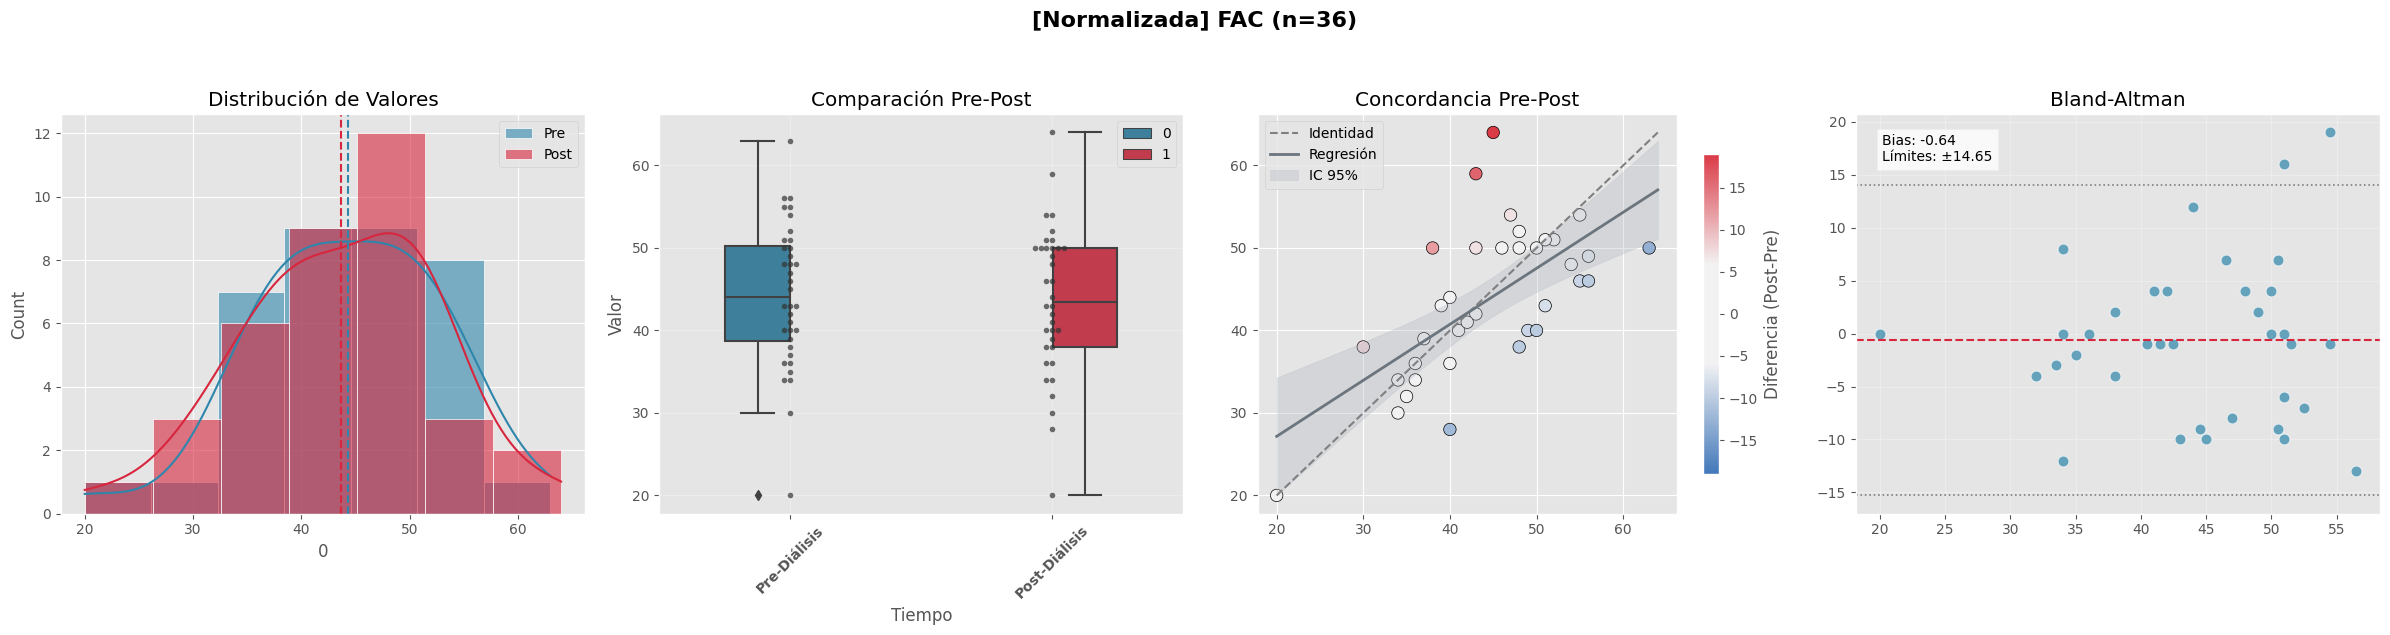


    📊 ANÁLISIS ESTADÍSTICO - FAC
    ▪ Diferencia media (IC 95%) [Estandarizada]: -0.07 (-0.36 a 0.21)
    ▪ Diferencia media (IC 95%) [Original]: -0.64 (-3.08 a 1.80)
    ▪ Prueba de normalidad: W = 0.956, p = 0.1670
    ▪ Prueba seleccionada: t(35) = 0.51, p = 0.6112
    ▪ Tamaño del efecto (Cohen's d): -0.09
    ▪ Regresión: y = 13.58 + 0.68x (R² = 0.422)
    ▪ Tamaño de muestra requerido para detectar un efecto significativo en FAC: 1076 pacientes.
    
────────────────────────────────────────────────────────────────────────────────


/Users/bita/.pyenv/versions/3.10.6/envs/traditum/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/bita/.pyenv/versions/3.10.6/envs/traditum/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/bita/.pyenv/versions/3.10.6/envs/traditum/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/bita/.pyenv/versions/3.10.6/envs/traditum/lib/python3.10/site-packages/seaborn/_oldcore.py

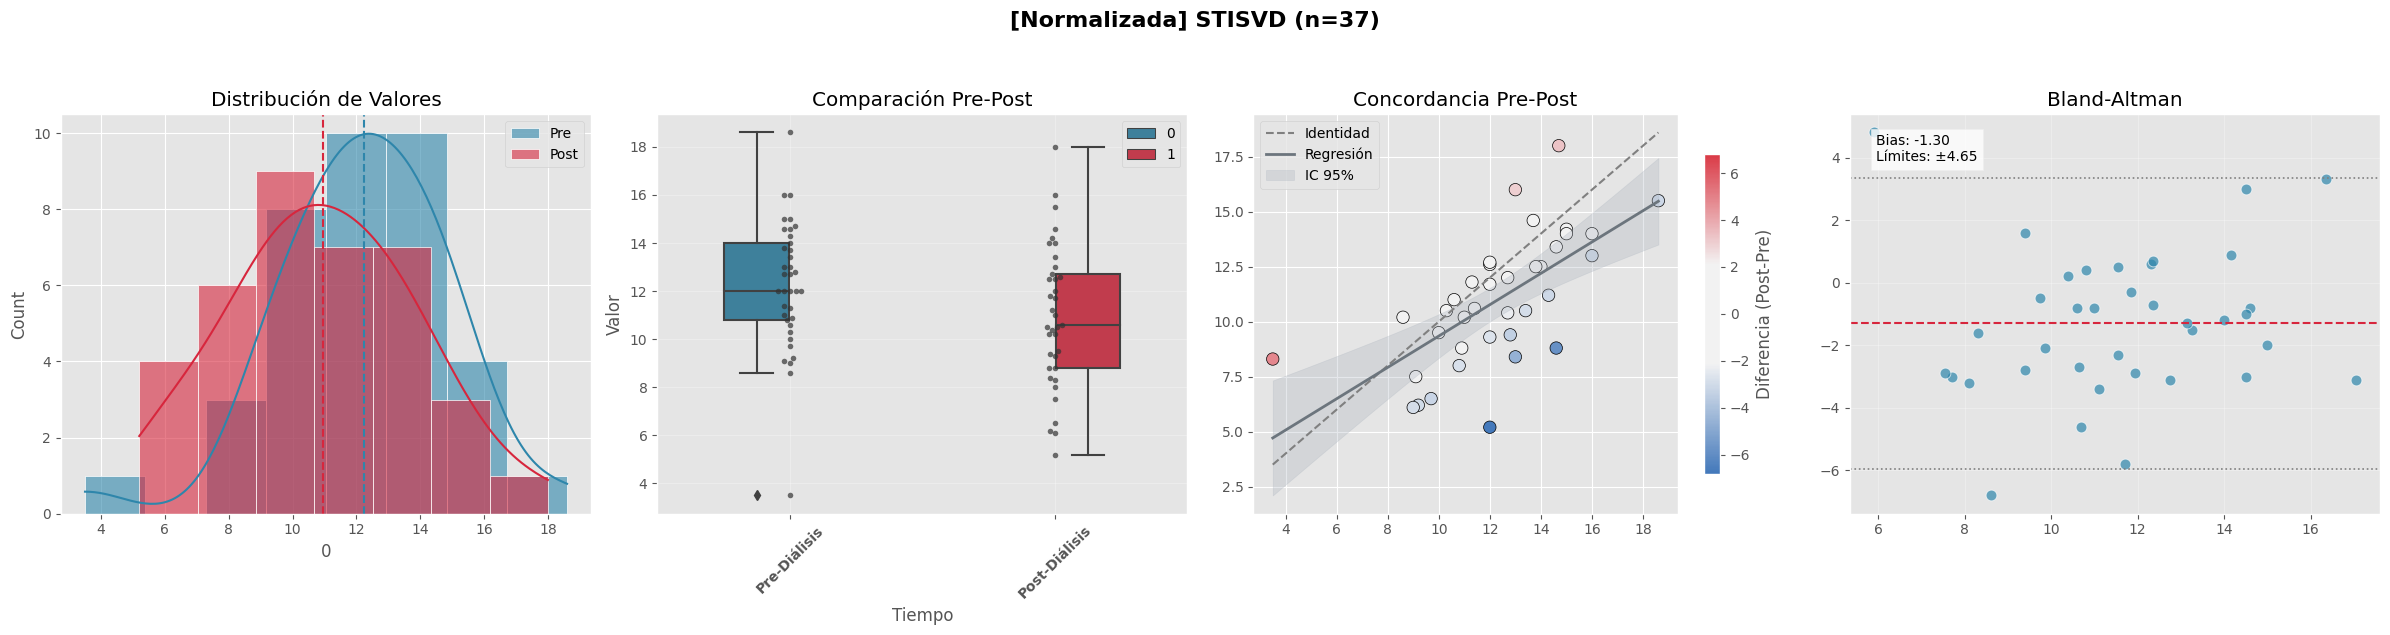


    📊 ANÁLISIS ESTADÍSTICO - STISVD
    ▪ Diferencia media (IC 95%) [Estandarizada]: -0.46 (-0.73 a -0.18)
    ▪ Diferencia media (IC 95%) [Original]: -1.30 (-2.07 a -0.54)
    ▪ Prueba de normalidad: W = 0.974, p = 0.5371
    ▪ Prueba seleccionada: t(36) = 3.34, p = 0.0019
    ▪ Tamaño del efecto (Cohen's d): -0.55
    ▪ Regresión: y = 2.22 + 0.71x (R² = 0.423)
    ▪ Tamaño de muestra requerido para detectar un efecto significativo en StisVD: 28 pacientes.
    
────────────────────────────────────────────────────────────────────────────────


/Users/bita/.pyenv/versions/3.10.6/envs/traditum/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/bita/.pyenv/versions/3.10.6/envs/traditum/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/bita/.pyenv/versions/3.10.6/envs/traditum/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/bita/.pyenv/versions/3.10.6/envs/traditum/lib/python3.10/site-packages/seaborn/_oldcore.py

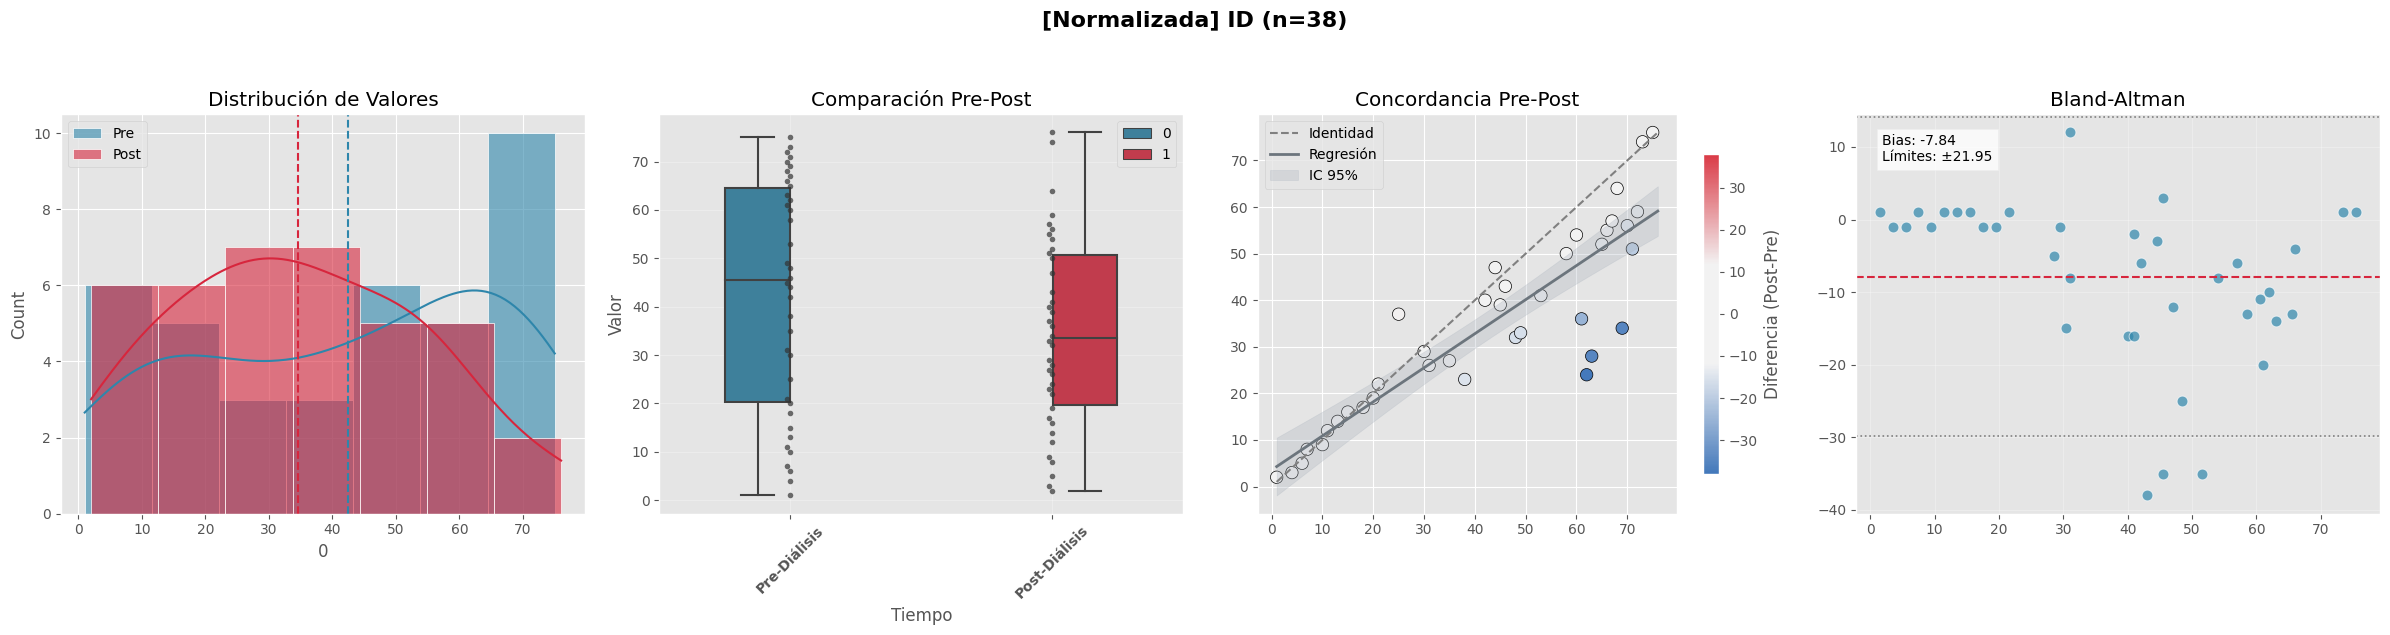

TypeError: wilcoxon() got an unexpected keyword argument 'method'

In [104]:
np.random.seed(42)

missing_threshold = 0.7
variables_ = [
    'vel it', 'Eeprim', 'AI vol index', 'TapPsap', 'grIT', 'StisVD', 'Id', 'FEy',
    'EA VD', 'EtisVD', 'Eeprim VD', '%fac', 'SFF', 'TAPSE', 'TEI', 'FAC', 'TAM',
    'TAD', 'TAS', 'Tdec', 'VCImax', 'EVD', 'A VD', 'Eprim', 'FC', 'DDVI', 'IDDVI',
    'DSVI', 'VTI', 'GC', 'IC', 'VS', 'IVS', 'IMVI', 'VD1', 'VD2', 'VD3', 'VCImin',
    'Colap', 'Ssup', 'Dsup', 'PSAP', 'BALANCE', 'KtV', 'Anillo', 'Portmx', 'Portmin'
]

scaler = StandardScaler()
df_z = df.copy()
df_z[variables_] = scaler.fit_transform(df[variables_])
df_z = df_z.add_suffix('_z') if len(variables_) > 0 else df.copy()

plt.style.use('ggplot')
sns.set_palette(["#2E86AB", "#D7263D"])

static_cols = [
    'Paciente', 'POSDIAL', 'Acceso', 'SEX', 'EDAD', 'HTA', 'DBT', 'DLP', 'AHF',
    'TBQ', 'BB', 'BCA', 'IECA', 'PESO','TALLA', 'ARA II', 'ARNI', 'MRA', 'SGLT',
    'INSULINA', 'HTO', 'HB', 'ALBUMIN', 'SC'
]

delete_cols = [
    'rumble','DIAL DESD', 'DiastolMITRAL', 'Id1', 'Id', 'ConMS 1', 'VD global', 'POR1', 'Cav 1', 'CONG', 'CEmodsev', 'SUPRAH', 'DIASTOL', 'FEVI',
    'FAV', 'bal 1500', 'bal 1500-3000', 'bal 3000', 'SC', 'SIV', 'PP',
    'AD dil', 'VD1dil', 'VD2dil', 'VD3dil', 'derra'
]

columns_to_drop = static_cols + problem_cols
initial_variables = df.drop(columns=columns_to_drop).columns.tolist()

missing_stats = []
for var in initial_variables:
    pre_missing = df[df['POSDIAL'] == 0][var].isna().mean()
    post_missing = df[df['POSDIAL'] == 1][var].isna().mean()
    max_missing = max(pre_missing, post_missing)
    missing_stats.append((var, max_missing))

variables_to_analyze = [var for var, missing in missing_stats if missing <= missing_threshold]

print("═"*60)
print(f"Variables excluidas por >{missing_threshold:.0%} missing:")
print(set(initial_variables) - set(variables_to_analyze))
print("═"*60)

def analyze_missing_data(df, variables, covariates=['HTA', 'DBT', 'SEX', 'DLP']):
    missing_summary = []
    for var in variables:
        total_pacientes = df['Paciente'].nunique()
        pre_missing = df[df['POSDIAL'] == 0][var].isna().sum()
        post_missing = df[df['POSDIAL'] == 1][var].isna().sum()
        merged = df.pivot(index='Paciente', columns='POSDIAL', values=var).dropna()
        n_paired = len(merged)
        mcar_results = {}
        for covar in covariates:
            try:
                if df[covar].dtype == 'object' or df[covar].nunique() < 5:
                    contingency = pd.crosstab(df[var].isna(), df[covar])
                    _, pval, _, _ = chi2_contingency(contingency)
                else:
                    present_data = df[df[var].notna()][covar]
                    missing_data = df[df[var].isna()][covar]
                    _, pval = ttest_ind(present_data, missing_data, nan_policy='omit')
                mcar_results[covar] = f"{pval:.3f}"
            except:
                mcar_results[covar] = "Error"
        missing_summary.append({
            'Variable': var, 'Pacientes Totales': total_pacientes,
            'Pre-Missing (%)': f"{(pre_missing/total_pacientes)*100:.1f}%",
            'Post-Missing (%)': f"{(post_missing/total_pacientes)*100:.1f}%",
            'Pares Completos': n_paired, 'MCAR_HTA': mcar_results['HTA'],
            'MCAR_DBT': mcar_results['DBT'], 'MCAR_SEX': mcar_results['SEX'],
            'MCAR_DLP': mcar_results['DLP'], 'Significativas (p<0.05)': sum(
                1 for v in mcar_results.values() if isinstance(v, str) and v.replace('.','').isdigit() and float(v) < 0.05)
        })
    return pd.DataFrame(missing_summary)

def calcular_tamano_muestra(df, variable, alpha=0.05, potencia=0.80):
    """
    Calcula el tamaño de muestra necesario basado en la desviación estándar
    real de la diferencia pre-post en la variable dada.
    """
    merged = df.pivot(index='Paciente', columns='POSDIAL', values=variable).dropna()
    diffs = merged[1] - merged[0]  # Diferencia post-pre

    tamano_efecto = diffs.mean() / diffs.std(ddof=1)  # Cohen's d real
    power_analysis = TTestPower()
    n = power_analysis.solve_power(effect_size=tamano_efecto, alpha=alpha, power=potencia, alternative='two-sided')

    return math.ceil(n)


def paired_analysis(df, df_z, variable, min_paired=10, alpha=0.05, potencia=0.80, tamano_efecto=0.5):
    n_requerido = calcular_tamano_muestra(df, variable)

    merged = df.pivot(index='Paciente', columns='POSDIAL', values=variable).dropna()
    n = len(merged)

    if n < min_paired:
        print(f"\n⚠ {variable}: Datos insuficientes (n={n})")
        return


    merged_z = df_z.pivot(index='Paciente_z', columns='POSDIAL_z', values=f"{variable}_z").dropna()
    pre, post = merged[0], merged[1]
    pre_z, post_z = merged_z[0], merged_z[1]
    diffs, diffs_z = post - pre, post_z - pre_z

    norm_flag = "[Normalizada] " if variable in variables_ else ""
    mean_diff_z, sd_diff_z = diffs_z.mean(), diffs_z.std(ddof=1)
    t_critical = t.ppf(0.975, df=n-1)
    ci_lower_z = mean_diff_z - t_critical * (sd_diff_z/np.sqrt(n))
    ci_upper_z = mean_diff_z + t_critical * (sd_diff_z/np.sqrt(n))
    cohen_d_z = mean_diff_z / sd_diff_z

    shapiro_stat, shapiro_p = shapiro(diffs_z)
    X = sm.add_constant(pre)
    modelo = sm.OLS(post, X).fit()
    beta0, beta1 = modelo.params
    r2 = modelo.rsquared

    fig, axs = plt.subplots(1, 4, figsize=(24, 6), dpi=100)
    fig.suptitle(f"{norm_flag}{variable.upper()} (n={n})", fontsize=16, y=1.05, fontweight='bold')

    sns.histplot(pre, ax=axs[0], color='#2E86AB', kde=True, edgecolor='w', alpha=0.6, label='Pre')
    sns.histplot(post, ax=axs[0], color='#D7263D', kde=True, edgecolor='w', alpha=0.6, label='Post')
    axs[0].axvline(pre.mean(), color='#2E86AB', linestyle='--', linewidth=1.5)
    axs[0].axvline(post.mean(), color='#D7263D', linestyle='--', linewidth=1.5)
    axs[0].set_title('Distribución de Valores')
    axs[0].legend()

    melted = pd.melt(merged.reset_index(), id_vars='Paciente', value_vars=[0,1], var_name='Tiempo', value_name='Valor')
    sns.boxplot(x='Tiempo', y='Valor', data=melted, ax=axs[1], width=0.5, linewidth=1.5, hue='Tiempo')
    axs[1].set_xticks([0, 1])
    axs[1].set_xticklabels(['Pre-Diálisis', 'Post-Diálisis'], fontweight='bold', rotation=45)
    sns.swarmplot(x='Tiempo', y='Valor', data=melted, ax=axs[1], color='#333333', size=4, alpha=0.7)
    axs[1].set_title('Comparación Pre-Post')
    axs[1].grid(True, alpha=0.3)

    min_val, max_val = min(pre.min(), post.min()), max(pre.max(), post.max())
    x_pred = np.linspace(min_val, max_val, 100)
    X_pred = sm.add_constant(x_pred)
    y_pred = modelo.predict(X_pred)
    pred_int = modelo.get_prediction(X_pred).conf_int()
    palette = sns.diverging_palette(250, 10, sep=80, as_cmap=True)
    vmax = max(abs(diffs.max()), abs(diffs.min()))
    scatter = axs[2].scatter(pre, post, c=diffs, cmap=palette, vmin=-vmax, vmax=vmax, edgecolor='k', s=80)
    plt.colorbar(scatter, ax=axs[2], shrink=0.8).set_label('Diferencia (Post-Pre)')
    axs[2].plot([min_val, max_val], [min_val, max_val], '--', color='gray', label="Identidad")
    axs[2].plot(x_pred, y_pred, color='#6C757D', linewidth=2, label="Regresión")
    axs[2].fill_between(x_pred, pred_int[:,0], pred_int[:,1], color='#AAB2BD', alpha=0.3, label="IC 95%")
    axs[2].set_title('Concordancia Pre-Post')
    axs[2].legend()

    avg = (pre + post)/2
    mean_diff = diffs.mean()
    std_diff = diffs.std(ddof=1)
    upper_loa = mean_diff + 1.96 * std_diff
    lower_loa = mean_diff - 1.96 * std_diff
    sns.scatterplot(x=avg, y=diffs, ax=axs[3], color='#2E86AB', s=60, alpha=0.7)
    axs[3].axhline(mean_diff, color='#D7263D', linestyle='--', linewidth=1.5)
    axs[3].axhline(upper_loa, color='gray', linestyle=':', linewidth=1.2)
    axs[3].axhline(lower_loa, color='gray', linestyle=':', linewidth=1.2)
    axs[3].text(0.05, 0.95, f'Bias: {mean_diff:.2f}\nLímites: ±{1.96*std_diff:.2f}',
                transform=axs[3].transAxes, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.8))
    axs[3].set_title('Bland-Altman')
    axs[3].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    if shapiro_p > 0.05:
        test_result = ttest_rel(pre_z, post_z)
        test_type = f"t({n-1}) = {test_result.statistic:.2f}, p = {test_result.pvalue:.4f}"
    else:
        test_result = wilcoxon(pre_z, post_z, method='approx')
        Z = (test_result.statistic - (n*(n+1)/4)) / np.sqrt(n*(n+1)*(2*n+1)/24)
        test_type = f"Z = {Z:.3f}, p = {test_result.pvalue:.4f}"

    print(f"""
    📊 ANÁLISIS ESTADÍSTICO - {variable.upper()}
    ▪ Diferencia media (IC 95%) [Estandarizada]: {mean_diff_z:.2f} ({ci_lower_z:.2f} a {ci_upper_z:.2f})
    ▪ Diferencia media (IC 95%) [Original]: {diffs.mean():.2f} ({diffs.mean()-1.96*diffs.std()/np.sqrt(n):.2f} a {diffs.mean()+1.96*diffs.std()/np.sqrt(n):.2f})
    ▪ Prueba de normalidad: W = {shapiro_stat:.3f}, p = {shapiro_p:.4f}
    ▪ Prueba seleccionada: {test_type}
    ▪ Tamaño del efecto (Cohen's d): {cohen_d_z:.2f}
    ▪ Regresión: y = {beta0:.2f} + {beta1:.2f}x (R² = {r2:.3f})
    ▪ Tamaño de muestra requerido para detectar un efecto significativo en {variable}: {n_requerido} pacientes.
    """)
    print('─'*80)

missing_df = analyze_missing_data(df, variables_to_analyze)
print("\n[ANÁLISIS DE VALORES PERDIDOS - VARIABLES INCLUIDAS]")
print(tabulate(missing_df, headers='keys', tablefmt='pretty', showindex=False))

print("ANÁLISIS LONGITUDINAL PAREADO")
print("═"*60)
for var in variables_to_analyze:
    paired_analysis(df, df_z, var)

# MATERIALES Y *METODOS*

**2.4. Manejo de Datos y Análisis Estadístico**

*2.4.1. Preprocesamiento:*

*Valores faltantes:* 

Mediante análisis multivariado (Missing Completely at Random, MCAR), se evaluó la asociación de datos faltantes con variables clínicas clave (hipertensión, diabetes, sexo, dislipidemia) usando pruebas χ² (categóricas) y t-test (continuas). Variables con >30% faltantes en cualquier momento (pre/post) se excluyeron del análisis longitudinal.

*Normalización:*

Variables con unidades no directamente interpretables (e.g., índices ecocardiográficos derivados) se estandarizaron mediante escalado Z.
2.4.2. Análisis Estadístico:

*Normalidad:*

Evaluada con prueba de Shapiro-Wilk (α=0.05).

*Comparaciones pre-post:*

t-test pareado (datos normales) o prueba de Wilcoxon (no paramétricos), aplicados a datos estandarizados para homogenizar escalas.

*Tamaño del efecto:*

Cohen’s d en escala estandarizada (d=0.2: pequeño; d=0.5: moderado; d≥0.8: grande).

*Concordancia:*

Modelos de regresión lineal con IC 95% y gráficos de Bland-Altman (límites de acuerdo: ±1.96 DE).

*Visualización:* Histogramas superpuestos, diagramas de caja con swarmplots, y análisis de tendencia.

**2.4.3. Consideraciones Éticas y Software:**

Los datos se anonimizaron asignando identificadores únicos no vinculables. El análisis se implementó en Python 3.10 (SciPy v1.11, pandas v2.0.3, statsmodels v0.14), con visualización en matplotlib v3.7.1 y seaborn v0.12.2. El código cumple estándares FAIR y está disponible en [repositorio].